# LSTM for Covariance Matrix

In [55]:
import numpy as np
import pandas as pd
import yfinance as yf

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

from gen_seq_data import SequenceDataset
from vech import vech, unvech

from torch.utils.data import Dataset, DataLoader
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import matplotlib.pyplot as plt
plt.style.use('ggplot')

import time

device = "mps" if torch.backends.mps.is_available() else "cpu"

## Price Data

In [56]:
macro_tickers = [
    "^GSPC",  # Equity (S&P 500)
    "GC=F",   # Gold
    "CL=F",   # Oil
    "^TNX"    # 10Y yield
]

macro_btc_tickers = [
    "^GSPC",
    "GC=F",
    "CL=F",
    "^TNX",
    "BTC-USD"
]

In [57]:
#tickers = "^GSPC BTC-USD GC=F"  # S&P 500 index
macro_data = yf.download(macro_tickers, period="max")
macro_btc_data = yf.download(macro_btc_tickers, period="max")

/var/folders/94/8_7g7dqx72760sk83dk1klgc0000gn/T/ipykernel_68310/3627831171.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  macro_data = yf.download(macro_tickers, period="max")
[*********************100%***********************]  4 of 4 completed
/var/folders/94/8_7g7dqx72760sk83dk1klgc0000gn/T/ipykernel_68310/3627831171.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  macro_btc_data = yf.download(macro_btc_tickers, period="max")
[*********************100%***********************]  5 of 5 completed


In [58]:
macro_data

Price           Close                                         High  \
Ticker           CL=F         GC=F        ^GSPC   ^TNX        CL=F   
Date                                                                 
1927-12-30        NaN          NaN    17.660000    NaN         NaN   
1928-01-03        NaN          NaN    17.760000    NaN         NaN   
1928-01-04        NaN          NaN    17.719999    NaN         NaN   
1928-01-05        NaN          NaN    17.549999    NaN         NaN   
1928-01-06        NaN          NaN    17.660000    NaN         NaN   
...               ...          ...          ...    ...         ...   
2026-04-08  94.410004  4749.500000  6782.810059  4.291  109.190002   
2026-04-09  97.870003  4792.200195  6824.660156  4.293  102.699997   
2026-04-10  96.570000  4761.899902  6816.890137  4.317  100.419998   
2026-04-13  99.080002  4742.399902  6886.240234  4.297  105.629997   
2026-04-14  97.139999  4793.700195          NaN    NaN   98.000000   

Price                                              Low               \
Ticker             GC=F        ^GSPC   ^TNX       CL=F         GC=F   
Date                                                                  
1927-12-30          NaN    17.660000    NaN        NaN          NaN   
1928-01-03          NaN    17.760000    NaN        NaN          NaN   
1928-01-04          NaN    17.719999    NaN        NaN          NaN   
1928-01-05          NaN    17.549999    NaN        NaN          NaN   
1928-01-06          NaN    17.660000    NaN        NaN          NaN   
...                 ...          ...    ...        ...          ...   
2026-04-08  4851.000000  6793.500000  4.297  91.050003  4738.799805   
2026-04-09  4799.100098  6835.310059  4.321  95.250000  4711.000000   
2026-04-10  4791.000000  6845.770020  4.323  95.510002  4744.899902   
2026-04-13  4742.399902  6887.000000  4.351  97.029999  4704.000000   
2026-04-14  4820.399902          NaN    NaN  95.199997  4767.600098   

Price                                 Open                                   \
Ticker            ^GSPC   ^TNX        CL=F         GC=F        ^GSPC   ^TNX   
Date                                                                          
1927-12-30    17.660000    NaN         NaN          NaN    17.660000    NaN   
1928-01-03    17.760000    NaN         NaN          NaN    17.760000    NaN   
1928-01-04    17.719999    NaN         NaN          NaN    17.719999    NaN   
1928-01-05    17.549999    NaN         NaN          NaN    17.549999    NaN   
1928-01-06    17.660000    NaN         NaN          NaN    17.660000    NaN   
...                 ...    ...         ...          ...          ...    ...   
2026-04-08  6740.279785  4.234  108.739998  4760.000000  6754.359863  4.248   
2026-04-09  6761.549805  4.260   96.779999  4711.000000  6783.689941  4.297   
2026-04-10  6808.459961  4.277   98.230003  4745.899902  6839.240234  4.285   
2026-04-13  6790.020020  4.297  102.000000  4704.000000  6806.470215  4.349   
2026-04-14          NaN    NaN   97.989998  4769.299805          NaN    NaN   

Price         Volume                              
Ticker          CL=F     GC=F         ^GSPC ^TNX  
Date                                              
1927-12-30       NaN      NaN  0.000000e+00  NaN  
1928-01-03       NaN      NaN  0.000000e+00  NaN  
1928-01-04       NaN      NaN  0.000000e+00  NaN  
1928-01-05       NaN      NaN  0.000000e+00  NaN  
1928-01-06       NaN      NaN  0.000000e+00  NaN  
...              ...      ...           ...  ...  
2026-04-08  599576.0    405.0  5.904880e+09  0.0  
2026-04-09  427201.0   1277.0  4.912410e+09  0.0  
2026-04-10  314855.0    812.0  4.393220e+09  0.0  
2026-04-13  314855.0    812.0  4.785840e+09  0.0  
2026-04-14   55874.0  45738.0           NaN  NaN  

[24720 rows x 20 columns]

In [59]:
close = macro_data["Close"].copy().dropna()

In [60]:
len(close)

6416

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

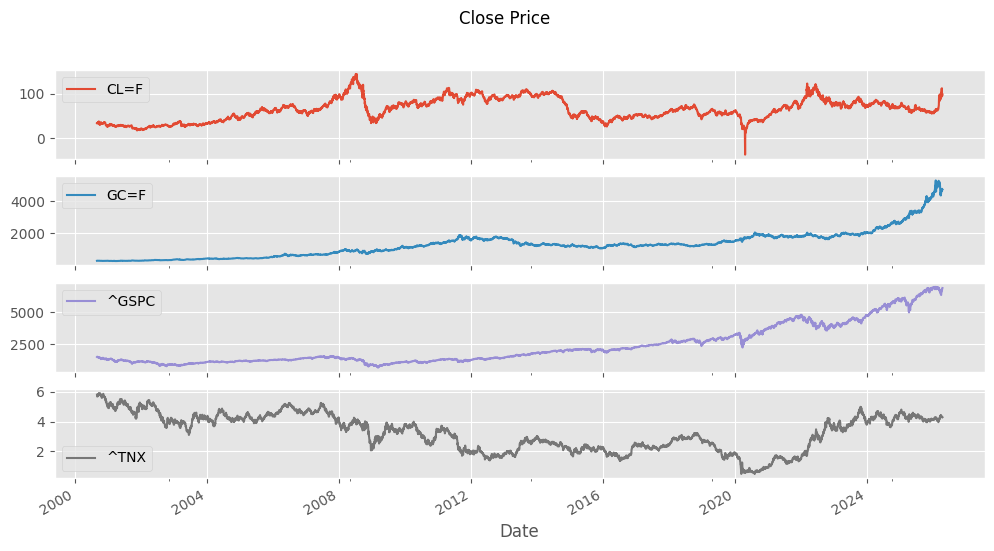

In [61]:
close.plot(title="Close Price", subplots=True, figsize=(12, 6))

/Users/bayesed/.pyenv/versions/3.13.7/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

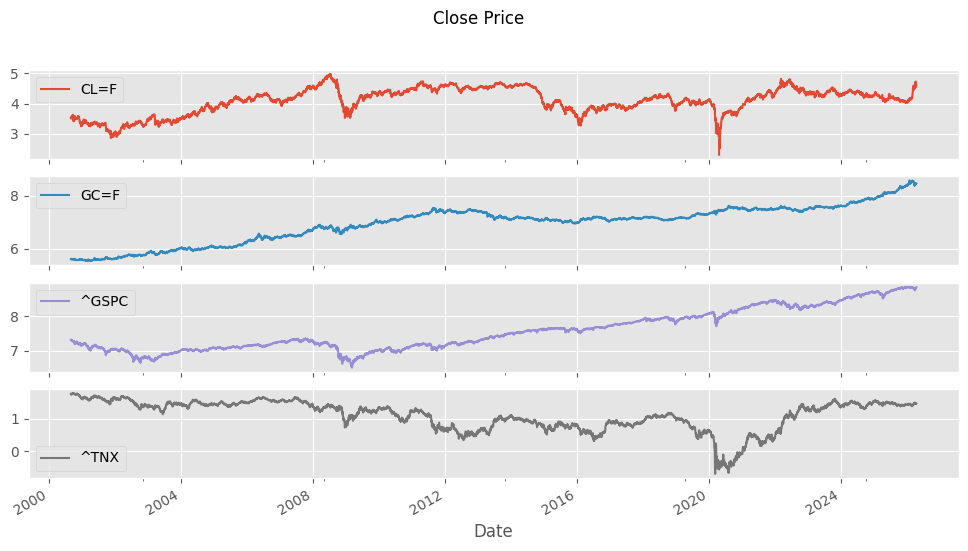

In [62]:
np.log(close).plot(title="Close Price", subplots=True, figsize=(12, 6))

In [63]:
logret = np.log(close).diff() # log(P_t) - log(P_{t-1})) = log(P_t / P_{t-1})
logret["^TNX"] = close["^TNX"].diff() # r_t(yiel) = P_t(yield) - P_{t-1}(yield)

# Aufräumen: erste Zeile NaN durch diff, ggf. weitere NaNs durch Datenlücken
logret = logret.dropna()

logret.head(), logret.tail()

/Users/bayesed/.pyenv/versions/3.13.7/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


(Ticker          CL=F      GC=F     ^GSPC   ^TNX
 Date                                           
 2000-08-31 -0.009023  0.015937  0.009993 -0.071
 2000-09-01  0.008424 -0.004682  0.002034 -0.054
 2000-09-05  0.012504 -0.004342 -0.009043  0.008
 2000-09-06  0.033458 -0.005818 -0.009889  0.029
 2000-09-07  0.010814 -0.000730  0.006852  0.037,
 Ticker          CL=F      GC=F     ^GSPC   ^TNX
 Date                                           
 2026-04-07  0.004792  0.000064  0.000759  0.008
 2026-04-08 -0.179298  0.019646  0.024772 -0.052
 2026-04-09  0.035993  0.008950  0.006151  0.002
 2026-04-10 -0.013372 -0.006343 -0.001139  0.024
 2026-04-13  0.025659 -0.004103  0.010122 -0.020)

In [64]:
len(logret)

6413

In [65]:
import os
from pathlib import Path

In [66]:
data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)

In [67]:
print(data_dir)

data


In [68]:
import datetime
datetime.datetime.now().strftime("%Y-%m-%d")

'2026-04-14'

In [69]:
f"logret_{datetime.datetime.now().strftime('%Y-%m-%d')}.csv"

'logret_2026-04-14.csv'

In [70]:
logret_export = logret[macro_tickers].copy()
logret_export.index.name = "Date"

logret_export.to_csv(data_dir / f"logret_{datetime.datetime.now().strftime('%Y-%m-%d')}.csv")

In [71]:
logret

Ticker,CL=F,GC=F,^GSPC,^TNX
Date,,,,
2000-08-31,-0.009023,0.015937,0.009993,-0.071
2000-09-01,0.008424,-0.004682,0.002034,-0.054
2000-09-05,0.012504,-0.004342,-0.009043,0.008
2000-09-06,0.033458,-0.005818,-0.009889,0.029
2000-09-07,0.010814,-0.000730,0.006852,0.037
...,...,...,...,...
2026-04-07,0.004792,0.000064,0.000759,0.008
2026-04-08,-0.179298,0.019646,0.024772,-0.052
2026-04-09,0.035993,0.008950,0.006151,0.002


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

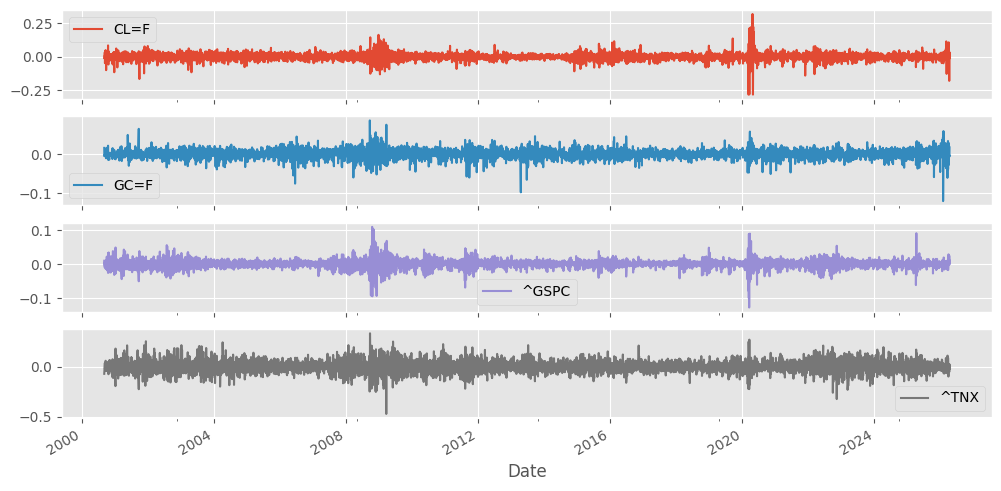

In [72]:
logret.plot(subplots=True, figsize=(12, 6))

array([[<Axes: title={'center': 'CL=F'}>,
        <Axes: title={'center': 'GC=F'}>],
       [<Axes: title={'center': '^GSPC'}>,
        <Axes: title={'center': '^TNX'}>]], dtype=object)

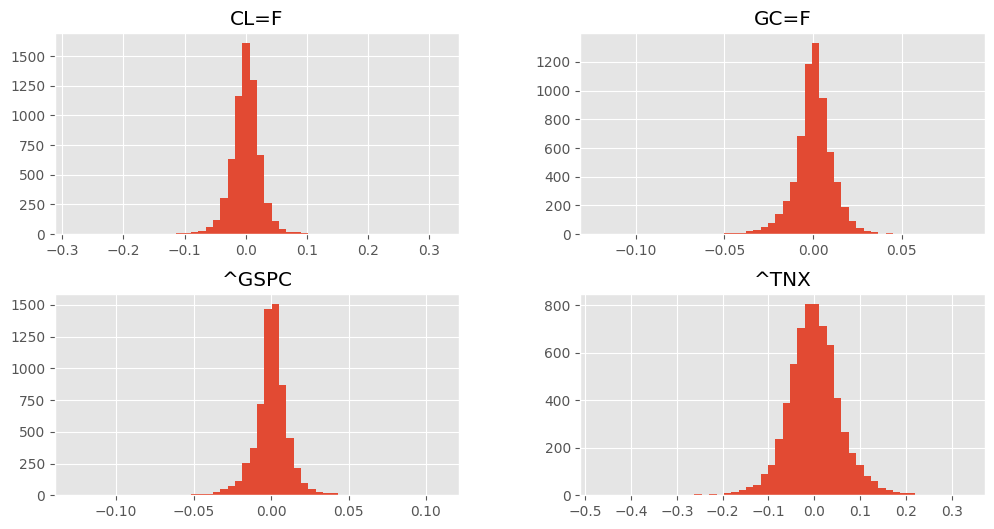

In [73]:
logret.hist(bins=50, figsize=(12, 6))

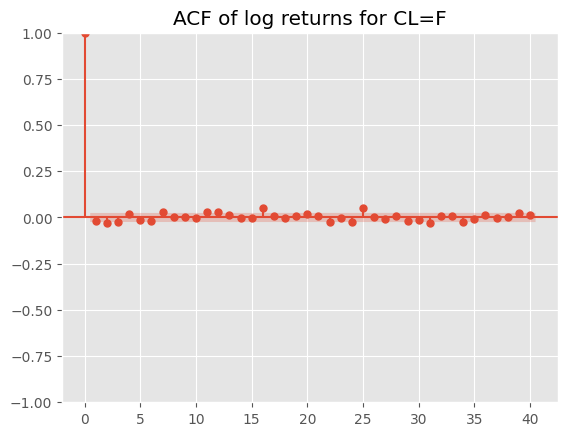

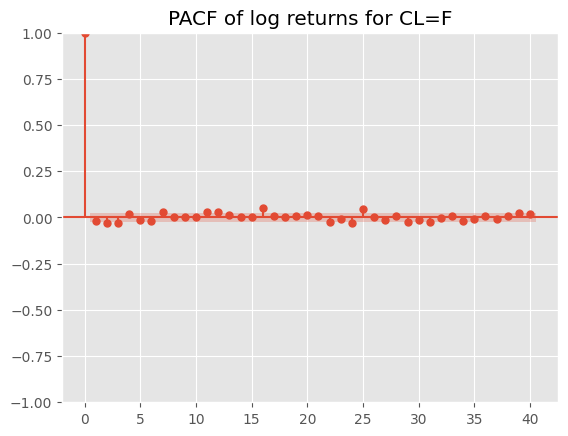

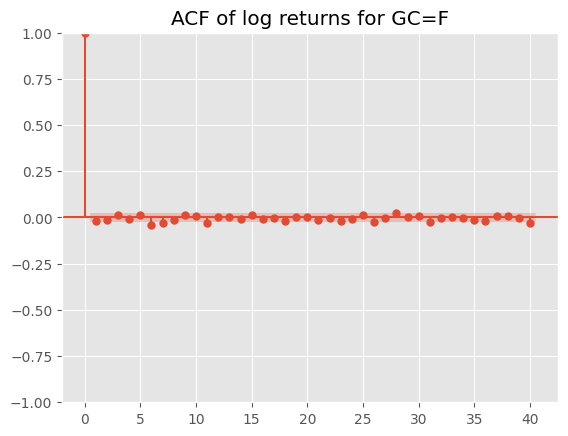

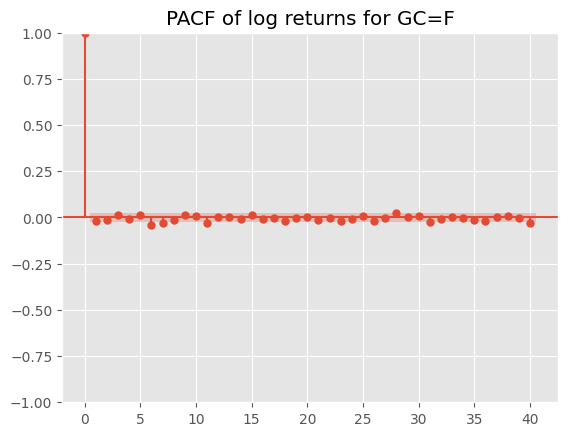

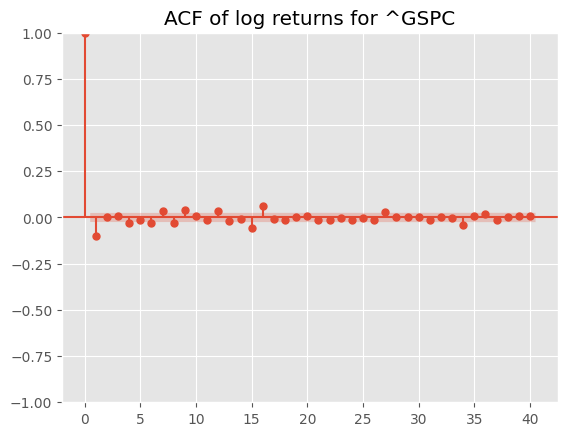

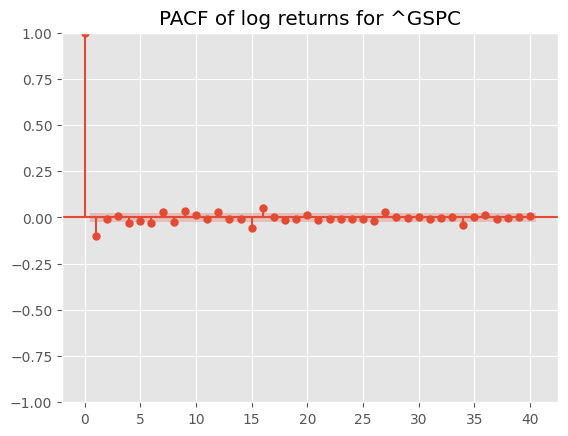

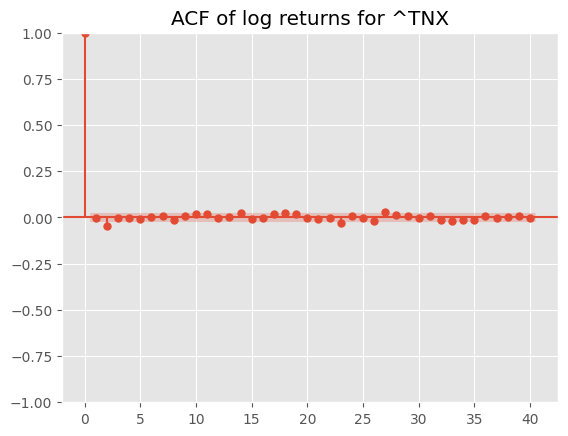

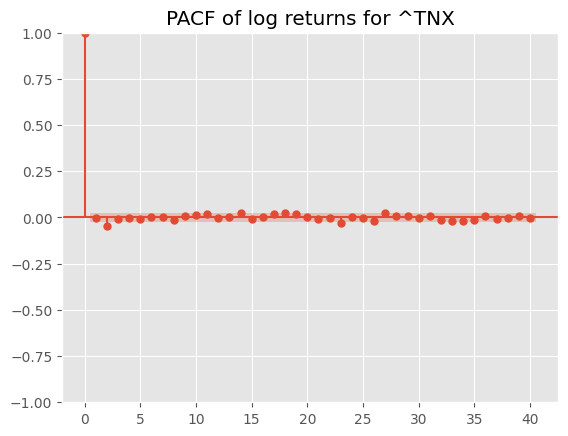

In [74]:
for col in logret.columns:
    plot_acf(logret[col], lags=40, title=f"ACF of log returns for {col}")
    plot_pacf(logret[col], lags=40, title=f"PACF of log returns for {col}")

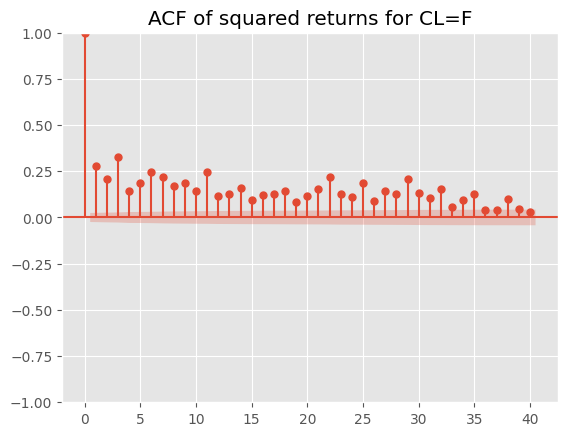

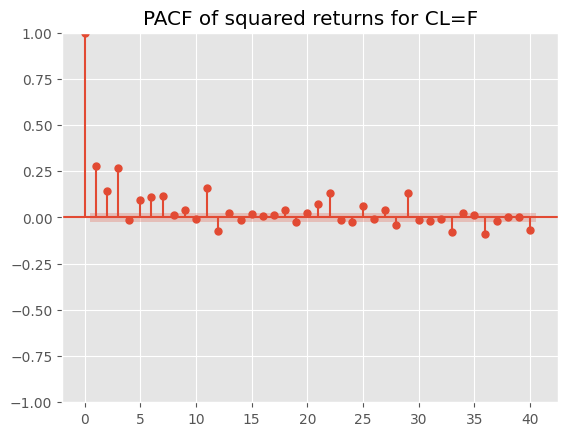

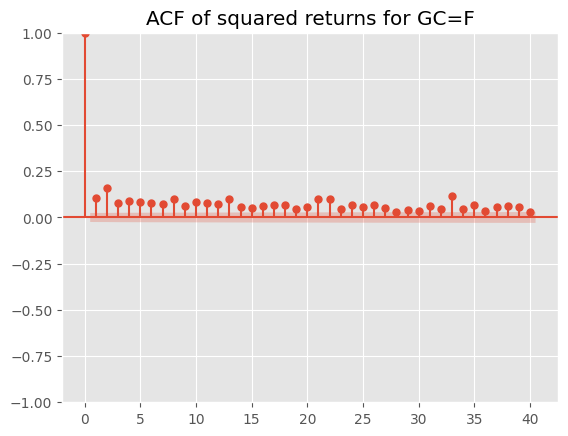

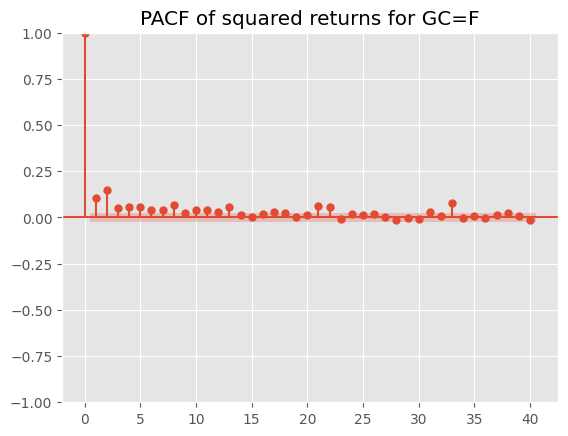

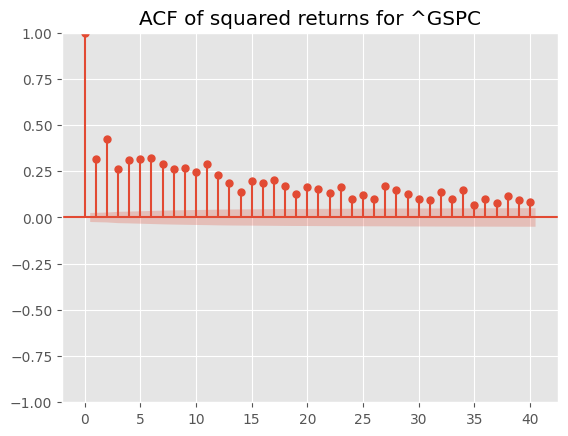

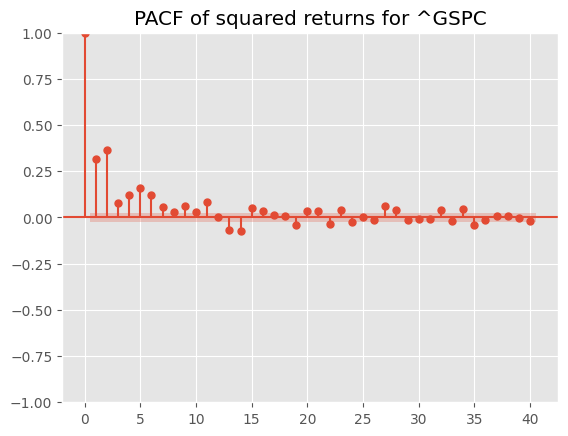

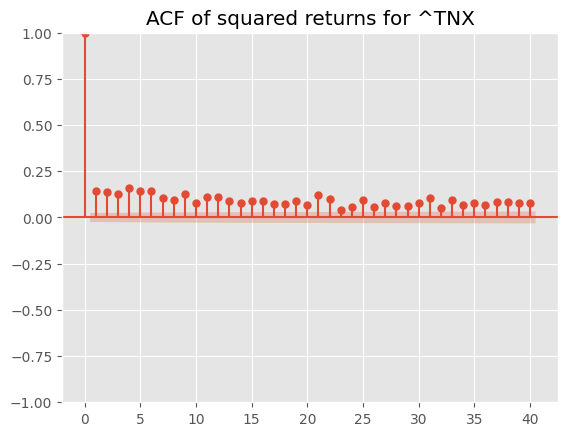

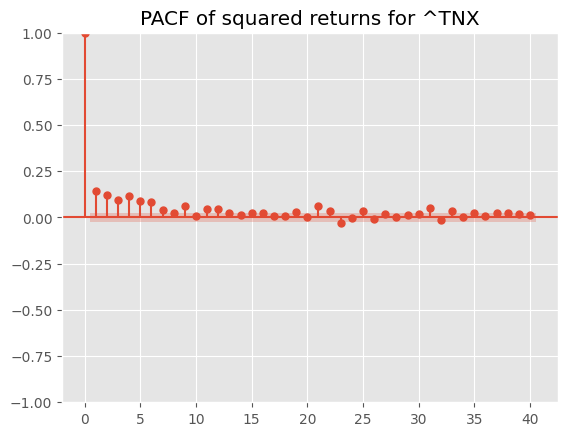

In [75]:
# squared returns
for col in logret.columns:
    plot_acf(logret[col]**2, lags=40, title=f"ACF of squared returns for {col}")
    plot_pacf(logret[col]**2, lags=40, title=f"PACF of squared returns for {col}")

In [76]:
from statsmodels.tsa.stattools import adfuller

for col in logret.columns:
    print(f"ADF test for {col}:")
    result = adfuller(logret[col])
    print(f"ADF statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print("---")
    

ADF test for CL=F:
ADF statistic: -14.412990955024945
p-value: 8.145989405148897e-27
---
ADF test for GC=F:
ADF statistic: -25.475546797659945
p-value: 0.0
---
ADF test for ^GSPC:
ADF statistic: -19.920714623660686
p-value: 0.0
---
ADF test for ^TNX:
ADF statistic: -59.49032429036658
p-value: 0.0
---


In [77]:
#feature_cols = macro_tickers.split(" ")

In [78]:
macro_tickers

['^GSPC', 'GC=F', 'CL=F', '^TNX']

In [79]:
R = logret[macro_tickers].values.astype(np.float32)   # (N,d)

# Outer products pro t: (N,d,1) * (N,1,d) -> (N,d,d)
U = R[:, :, None] * R[:, None, :]

In [80]:
cross_returns = vech(torch.tensor(U))
cross_returns.shape

torch.Size([6413, 10])

In [81]:
logret.shape

(6413, 4)

In [82]:
input_data = np.concatenate([logret[macro_tickers].values, cross_returns], axis=1)
input_df = pd.DataFrame(input_data, columns=macro_tickers + [f"cross_{i+1}" for i in range(cross_returns.shape[1])])

In [83]:
logret.index

DatetimeIndex(['2000-08-31', '2000-09-01', '2000-09-05', '2000-09-06',
               '2000-09-07', '2000-09-08', '2000-09-11', '2000-09-12',
               '2000-09-13', '2000-09-14',
               ...
               '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02',
               '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09',
               '2026-04-10', '2026-04-13'],
              dtype='datetime64[ns]', name='Date', length=6413, freq=None)

In [84]:
input_df.index = logret.index

In [85]:
input_df

,^GSPC,GC=F,CL=F,^TNX,cross_1,cross_2,cross_3,cross_4,cross_5,cross_6,cross_7,cross_8,cross_9,cross_10
Date,,,,,,,,,,,,,,
2000-08-31,0.009993,0.015937,-0.009023,-0.071,9.985256e-05,1.592482e-04,-0.000090,-0.000709,2.539743e-04,-1.437910e-04,-1.131498e-03,0.000081,0.000641,0.005041
2000-09-01,0.002034,-0.004682,0.008424,-0.054,4.136790e-06,-9.523008e-06,0.000017,-0.000110,2.192223e-05,-3.944083e-05,2.528339e-04,0.000071,-0.000455,0.002916
2000-09-05,-0.009043,-0.004342,0.012504,0.008,8.177266e-05,3.926019e-05,-0.000113,-0.000072,1.884936e-05,-5.428644e-05,-3.473223e-05,0.000156,0.000100,0.000064
2000-09-06,-0.009889,-0.005818,0.033458,0.029,9.779087e-05,5.753486e-05,-0.000331,-0.000287,3.385040e-05,-1.946606e-04,-1.687240e-04,0.001119,0.000970,0.000841
2000-09-07,0.006852,-0.000730,0.010814,0.037,4.694992e-05,-4.999942e-06,0.000074,0.000254,5.324698e-07,-7.891049e-06,-2.699923e-05,0.000117,0.000400,0.001369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-07,0.000759,0.000064,0.004792,0.008,5.760203e-07,4.893984e-08,0.000004,0.000006,4.158026e-09,3.090196e-07,5.158554e-07,0.000023,0.000038,0.000064
2026-04-08,0.024772,0.019646,-0.179298,-0.052,6.136539e-04,4.866812e-04,-0.004442,-0.001288,3.859807e-04,-3.522562e-03,-1.021613e-03,0.032148,0.009324,0.002704
2026-04-09,0.006151,0.008950,0.035993,0.002,3.783563e-05,5.505382e-05,0.000221,0.000012,8.010765e-05,3.221482e-04,1.790355e-05,0.001296,0.000072,0.000004


In [86]:
cross_df = pd.DataFrame(cross_returns, columns=[f"cross_{i+1}" for i in range(cross_returns.shape[1])])

In [87]:
cross_df

,cross_1,cross_2,cross_3,cross_4,cross_5,cross_6,cross_7,cross_8,cross_9,cross_10
0,9.985256e-05,1.592482e-04,-0.000090,-0.000709,2.539743e-04,-1.437910e-04,-1.131498e-03,0.000081,0.000641,0.005041
1,4.136790e-06,-9.523008e-06,0.000017,-0.000110,2.192223e-05,-3.944083e-05,2.528339e-04,0.000071,-0.000455,0.002916
2,8.177266e-05,3.926019e-05,-0.000113,-0.000072,1.884936e-05,-5.428644e-05,-3.473223e-05,0.000156,0.000100,0.000064
3,9.779087e-05,5.753486e-05,-0.000331,-0.000287,3.385040e-05,-1.946606e-04,-1.687240e-04,0.001119,0.000970,0.000841
4,4.694992e-05,-4.999942e-06,0.000074,0.000254,5.324698e-07,-7.891049e-06,-2.699923e-05,0.000117,0.000400,0.001369
...,...,...,...,...,...,...,...,...,...,...
6408,5.760203e-07,4.893984e-08,0.000004,0.000006,4.158026e-09,3.090196e-07,5.158554e-07,0.000023,0.000038,0.000064
6409,6.136539e-04,4.866812e-04,-0.004442,-0.001288,3.859807e-04,-3.522562e-03,-1.021613e-03,0.032148,0.009324,0.002704
6410,3.783563e-05,5.505382e-05,0.000221,0.000012,8.010765e-05,3.221482e-04,1.790355e-05,0.001296,0.000072,0.000004
6411,1.297708e-06,7.225650e-06,0.000015,-0.000027,4.023250e-05,8.481716e-05,-1.522279e-04,0.000179,-0.000321,0.000576


In [88]:
def train_val_test_split(df, train_size=0.7, val_size=0.15):
    n = len(df)
    test_end = int(n * train_size)
    val_end = int(n * (train_size + val_size))
    
    train_df = df.iloc[:test_end]
    val_df = df.iloc[test_end:val_end]
    test_df = df.iloc[val_end:]
    
    return train_df, val_df, test_df

In [89]:
train_df, val_df, test_df = train_val_test_split(input_df)

In [91]:
train_df.index.name

'Date'

In [92]:
train_df_expo = train_df[macro_tickers].copy()
train_df_expo.index.name = "Date"

train_df_expo.to_csv(data_dir / f"train_df_{datetime.datetime.now().strftime('%Y-%m-%d')}.csv")

val_df_expo = val_df[macro_tickers].copy()
val_df_expo.index.name = "Date"

val_df_expo.to_csv(data_dir / f"val_df_{datetime.datetime.now().strftime('%Y-%m-%d')}.csv")

test_df_expo = test_df[macro_tickers].copy()
test_df_expo.index.name = "Date"

test_df_expo.to_csv(data_dir / f"test_df_{datetime.datetime.now().strftime('%Y-%m-%d')}.csv")

## Vola

Wir modellieren nun
$\mathbf r_{t+1}\mid\mathcal F_t \sim \mathcal N(\mathbf 0, \Sigma_{t+1}),$
und lassen das LSTM direkt eine gueltige Kovarianzmatrix $\Sigma_{t+1}$ ausgeben.

Dazu parametrisieren wir $\Sigma_{t+1} = L_{t+1}L_{t+1}^\top$ mit einer unteren Dreiecksmatrix $L_{t+1}$ (Cholesky-Form).
Die Diagonale von $L_{t+1}$ wird mit `softplus` strikt positiv gemacht.


In [160]:
#feature_cols = tickers.split(" ")
mu = train_df.mean()
sigma = train_df.std() # vielleicht nicht durch die Std teilen

def normalize(df, mu, sigma, with_std=True):
    if with_std:
        return (df - mu) / sigma
    else:
        return df - mu

In [161]:
lookback = 60
batchsize = 128

In [162]:
train_norm = normalize(train_df, mu, sigma, with_std=True)
val_norm = normalize(val_df, mu, sigma, with_std=True)
test_norm = normalize(test_df, mu, sigma, with_std=True)

vol_train_ds = SequenceDataset(
    train_norm.values,
    train_norm[macro_tickers].values,
    lookback,
)
vol_val_ds = SequenceDataset(
    val_norm.values,
    val_norm[macro_tickers].values,
    lookback,
)
vol_test_ds = SequenceDataset(
    test_norm.values,
    test_norm[macro_tickers].values,
    lookback,
)

vol_train_loader = DataLoader(vol_train_ds, batch_size=batchsize, shuffle=True)
vol_val_loader = DataLoader(vol_val_ds, batch_size=batchsize, shuffle=False)
vol_test_loader = DataLoader(vol_test_ds, batch_size=batchsize, shuffle=False)


In [163]:
len(vol_train_ds), len(vol_val_ds), len(vol_test_ds)

(4421, 900, 901)

```train_cov```ggf. zur Initialisierung nutzen. 

In [164]:
train_cov = torch.cov(torch.tensor(train_norm[macro_tickers].values).T)  # sample / long-term covariance from training data
train_cov

tensor([[ 1.0000, -0.0335,  0.2121,  0.3630],
        [-0.0335,  1.0000,  0.2230, -0.1268],
        [ 0.2121,  0.2230,  1.0000,  0.1837],
        [ 0.3630, -0.1268,  0.1837,  1.0000]], dtype=torch.float64)

In [165]:
class LSTMCovariance(nn.Module):
    def __init__(self, input_size: int, n_assets: int, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.input_size = input_size
        self.n_assets = n_assets
        self.lower_tri_size = n_assets * (n_assets + 1) // 2

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, self.lower_tri_size)

    def forward(self, x: torch.Tensor):
        # x: (batch, lookback, d)
        out, _ = self.lstm(x) # BxTxh
        h_last = out[:, -1, :]  # Bxh letzter hidden state
        raw_covar = self.fc(h_last) # Bx(d(d+1)/2) raw lower-triangular elements

        L = unvech(raw_covar, self.n_assets) # Bxdxd, lower-triangular
        diag = F.softplus(torch.diagonal(L, dim1=-2, dim2=-1)) + 1e-4
        L = torch.tril(L, diagonal=-1) + torch.diag_embed(diag)
        sigma_t = L @ L.transpose(-1, -2) + 1e-4
        return sigma_t, L


def gaussian_nll(y: torch.Tensor, L: torch.Tensor) -> torch.Tensor:
    """
    y: (batch, d)
    chol: (batch, d, d), lower-triangular Cholesky factor of Sigma

    Returns per-sample negative log-likelihood for N(0, Sigma).
    """
    d = y.shape[-1] # 
    y_col = y.unsqueeze(-1) # Bxdx1

    # Solve Sigma^{-1}y via two triangular solves: L z = y, L^T x = z
    z = torch.linalg.solve_triangular(L, y_col, upper=False) # z = L^{-1} y
    precision_y = torch.linalg.solve_triangular(L.transpose(-1, -2), z, upper=True).squeeze(-1)
    mahal = (y * precision_y).sum(dim=-1) # y^T Sigma^{-1} y

    logdet = 2.0 * torch.log(torch.diagonal(L, dim1=-2, dim2=-1)).sum(dim=-1) # log(det(Sigma)) = log(det(L @ L^T)) = log(det(L)^2) = 2*log(det(L)) = 2*sum(log(diag(L)))
    const = d * np.log(2.0 * np.pi)

    return 0.5 * (const + logdet + mahal)

def student_nll(y: torch.Tensor, L: torch.Tensor, nu: float) -> torch.Tensor:
    """
    y: (batch, d)
    chol: (batch, d, d), lower-triangular Cholesky factor of Sigma
    nu: degrees of freedom

    Returns per-sample negative log-likelihood for multivariate Student-t with mean 0, scale Sigma, and nu degrees of freedom.
    """
    d = y.shape[-1]
    y_col = y.unsqueeze(-1)

    z = torch.linalg.solve_triangular(L, y_col, upper=False) # z = L^{-1} y
    precision_y = torch.linalg.solve_triangular(L.transpose(-1, -2), z, upper=True).squeeze(-1) # x = L^{-T} z = L^{-T} L^{-1} y = Sigma^{-1} y
    mahal = (y * precision_y).sum(dim=-1) # y^T Sigma^{-1} y

    logdet = 2.0 * torch.log(torch.diagonal(L, dim1=-2, dim2=-1)).sum(dim=-1) # log(det(Sigma)) = 2*sum(log(diag(L)))

    nu = torch.tensor(nu, device=y.device, dtype=y.dtype)
    d = torch.tensor(d, device=y.device, dtype=y.dtype)
    pi = torch.tensor(np.pi, device=y.device, dtype=y.dtype)
    
    const = (
        torch.lgamma((nu + d) / 2.0) - torch.lgamma(nu / 2.0) - 
        0.5 * d * torch.log(nu * pi) - 0.5 * logdet
    )

    return -const + 0.5 * (nu + d) * torch.log1p(mahal / nu)

In [166]:
def train_covariance_model(
    model,
    train_loader,
    val_loader,
    loss_fn=gaussian_nll,
    loss_kwargs=None,
    epochs=120,
    lr=1e-3,
    device="cpu",
    scheduler_type="plateau",   # "plateau", "cosine", None
    plateau_factor=0.5,
    plateau_patience=20,
    plateau_threshold=1e-3,
    min_lr=1e-6,
):
    start_time = time.perf_counter()

    if loss_kwargs is None:
        loss_kwargs = {}

    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)

    if scheduler_type == "plateau":
        scheduler = ReduceLROnPlateau(
            opt, mode="min", factor=plateau_factor, patience=plateau_patience, threshold=plateau_threshold, min_lr=min_lr
        )
    elif scheduler_type == "cosine":
        scheduler = CosineAnnealingLR(opt, T_max=epochs, eta_min=min_lr)
    else:
        scheduler = None

    history = {
        "train_batch_nll": [],
        "val_batch_nll": [],
        "train_epoch_nll": [],
        "val_epoch_nll": [],
        "lr": [],
    }
    best_val = float("inf")
    best_state = None


    for ep in range(1, epochs + 1):
        model.train()
        tr_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            opt.zero_grad()
            _, chol = model(xb)
            loss = loss_fn(yb, chol, **loss_kwargs).mean()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

            tr_losses.append(loss.item())

        model.eval()
        va_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                _, chol = model(xb)
                loss = loss_fn(yb, chol, **loss_kwargs).mean()
                va_losses.append(loss.item())

        tr = float(np.mean(tr_losses)) if tr_losses else np.nan
        va = float(np.mean(va_losses)) if va_losses else np.nan

        if scheduler is not None:
            if scheduler_type == "plateau":
                scheduler.step(va)
            else:
                scheduler.step()

        current_lr = opt.param_groups[0]["lr"]

        history["train_batch_nll"].append(tr_losses)
        history["val_batch_nll"].append(va_losses)
        history["train_epoch_nll"].append(tr)
        history["val_epoch_nll"].append(va)
        history["lr"].append(current_lr)

        print(f"Epoch {ep:03d} | train NLL {tr:.6f} | val NLL {va:.6f} | lr {current_lr:.2e}")

        if va < best_val:
            best_val = va
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    total_time = time.perf_counter() - start_time
    history["train_time_sec"] = total_time

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

In [167]:
from LSTMCovariance import LSTMCovariance
from training_functions import train_covariance_model, gaussian_nll, student_nll

In [168]:
k = len(macro_tickers)*(len(macro_tickers)+1)//2 # Anzahl an Cross Returns, die zusätzlich zu den normalen Returns als Input-Features für die Kovarianzmodellierung genutzt werden

cov_model = LSTMCovariance(input_size=(len(macro_tickers)+k), n_assets=len(macro_tickers), hidden_size=64, num_layers=2, dropout=0.2)
cov_model, hist = train_covariance_model(
    cov_model,
    vol_train_loader,
    vol_val_loader,
    epochs=500,
    lr=1e-4,
    plateau_patience=20,
    device=device,
    scheduler_type="cosine",  # oder "cosine"
)

Epoch 001 | train NLL 6.346609 | val NLL 7.209092 | lr 1.00e-04
Epoch 002 | train NLL 5.966073 | val NLL 6.805234 | lr 1.00e-04
Epoch 003 | train NLL 5.695558 | val NLL 6.415360 | lr 1.00e-04
Epoch 004 | train NLL 5.477327 | val NLL 6.072664 | lr 1.00e-04
Epoch 005 | train NLL 5.335704 | val NLL 5.828696 | lr 1.00e-04
Epoch 006 | train NLL 5.237183 | val NLL 5.648748 | lr 1.00e-04
Epoch 007 | train NLL 5.184342 | val NLL 5.542504 | lr 1.00e-04
Epoch 008 | train NLL 5.145625 | val NLL 5.477261 | lr 9.99e-05
Epoch 009 | train NLL 5.136549 | val NLL 5.447090 | lr 9.99e-05
Epoch 010 | train NLL 5.101255 | val NLL 5.400134 | lr 9.99e-05
Epoch 011 | train NLL 5.094265 | val NLL 5.390085 | lr 9.99e-05
Epoch 012 | train NLL 5.080206 | val NLL 5.386324 | lr 9.99e-05
Epoch 013 | train NLL 5.070686 | val NLL 5.351861 | lr 9.98e-05
Epoch 014 | train NLL 5.051595 | val NLL 5.342038 | lr 9.98e-05
Epoch 015 | train NLL 5.034224 | val NLL 5.326600 | lr 9.98e-05
Epoch 016 | train NLL 5.017993 | val NLL

In [169]:
from plots import plot_loss

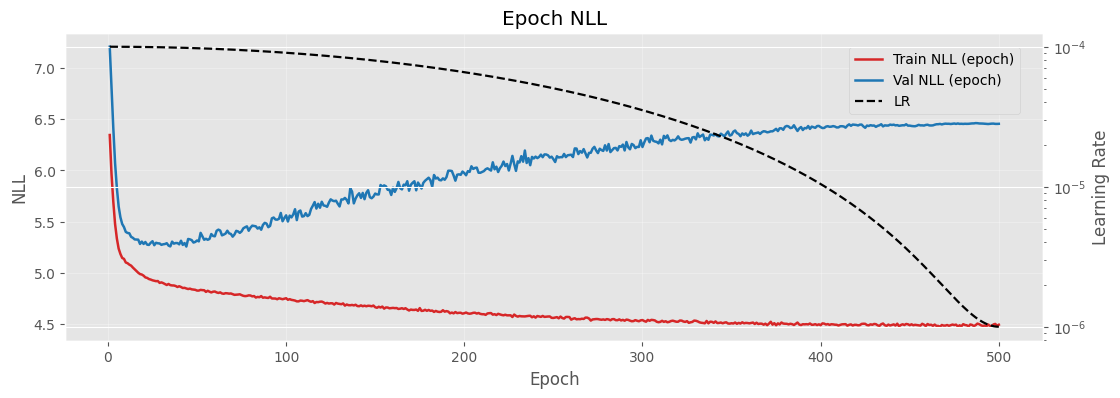

In [170]:
plot_loss(hist)

In [171]:
sigma

^GSPC       0.012016
GC=F        0.011294
CL=F        0.023773
^TNX        0.057919
cross_1     0.000479
cross_2     0.000225
cross_3     0.000493
cross_4     0.001175
cross_5     0.000347
cross_6     0.000380
cross_7     0.000888
cross_8     0.001402
cross_9     0.001849
cross_10    0.007080
dtype: float64

In [172]:
def predict_sigma(model, loader, device='cpu'):
    model.eval()
    sigmas = []
    targets = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            sigma_pred, _ = model(xb)
            sigmas.append(sigma_pred.cpu().numpy())
            targets.append(yb.numpy())

    return np.concatenate(sigmas, axis=0), np.concatenate(targets, axis=0)


sigma_val_scaled, y_val_scaled = predict_sigma(cov_model, vol_val_loader, device=device)
sigma_test_scaled, y_test_scaled = predict_sigma(cov_model, vol_test_loader, device=device)

# Transform covariance back to original return scale:
# if z = (r - mu)/std, then Cov(r) = D Cov(z) D with D = diag(std)

def scale_back(sigma_scaled, sigma=None, feature_cols=None):
    if sigma is not None and feature_cols is not None:
        std_vec = sigma[feature_cols].values.astype(np.float32)
        return sigma_scaled * std_vec[None, :, None] * std_vec[None, None, :]
    else:
        return sigma_scaled

sigma_val_real = scale_back(sigma_val_scaled, sigma=sigma, feature_cols=macro_tickers)
sigma_test_real = scale_back(sigma_test_scaled, sigma=sigma, feature_cols=macro_tickers)

print('sigma_val_scaled:', sigma_val_scaled.shape)
print('sigma_test_scaled:', sigma_test_scaled.shape)
print('sigma_test_real:', sigma_test_real.shape)
print('sigma_val_real:', sigma_val_real.shape)


sigma_val_scaled: (900, 4, 4)
sigma_test_scaled: (901, 4, 4)
sigma_test_real: (901, 4, 4)
sigma_val_real: (900, 4, 4)


In [173]:
vol_train_eval_loader = DataLoader(vol_train_ds, batch_size=batchsize, shuffle=False) # ohne Shuffle, für Plots

In [174]:
sigma_train_scaled, y_train_scaled = predict_sigma(cov_model, vol_train_eval_loader, device=device)
sigma_train_real = scale_back(sigma_train_scaled, sigma=sigma, feature_cols=macro_tickers)

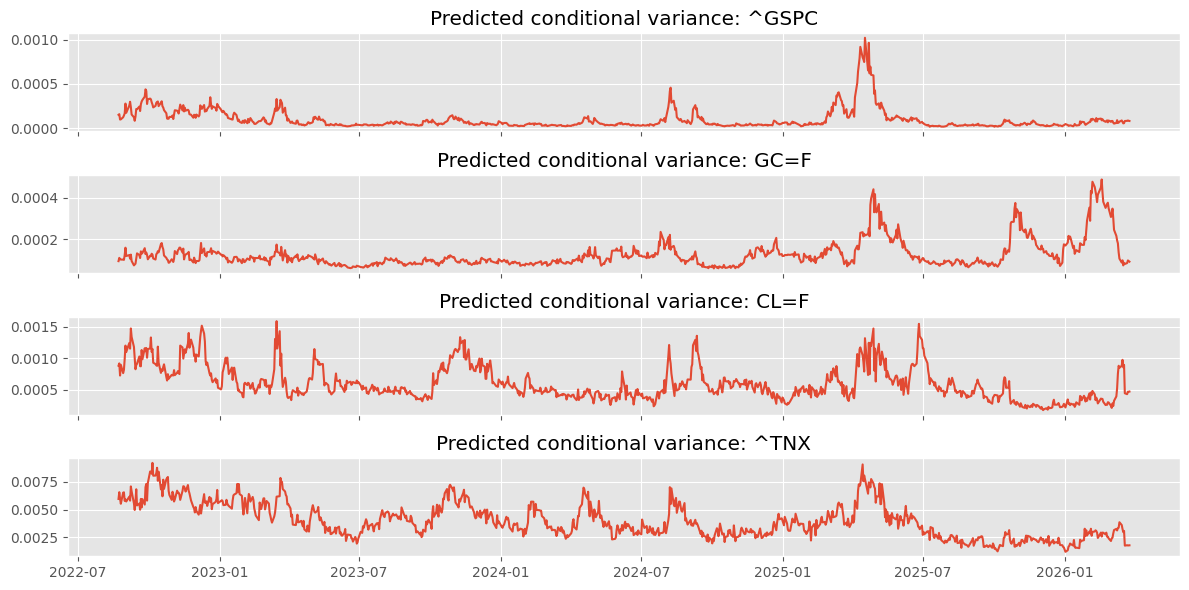

In [175]:
# Quick diagnostic plot: predicted conditional variances
# Build a time index + diagonal variance frame first
test_index_vol = test_df.index[lookback:]
sigma_test_diag_df = pd.DataFrame(
    {
        f'Var({macro_tickers[i]})': sigma_test_real[:, i, i]
        for i in range(len(macro_tickers))
    },
    index=test_index_vol,
)

fig, axes = plt.subplots(len(macro_tickers), 1, figsize=(12, 6), sharex=True)
if len(macro_tickers) == 1:
    axes = [axes]

for i, col in enumerate(macro_tickers):
    axes[i].plot(sigma_test_diag_df.index, sigma_test_diag_df[f'Var({col})'])
    axes[i].set_title(f'Predicted conditional variance: {col}')

plt.tight_layout()
plt.show()


In [176]:
from statistics import NormalDist
from scipy.stats import t

In [177]:
def plot_var(alpha=0.01, lookback=lookback, cols=macro_tickers, view="Test-Split", df=test_df, pred_vol=sigma_test_real, portfolio=False, portfolio_df=None, loss_fn=gaussian_nll, loss_kwargs=None):

    if loss_fn == gaussian_nll:
        z_lo = NormalDist().inv_cdf(alpha)        # z_{alpha}, z.B. -2.326
        z_hi = NormalDist().inv_cdf(1.0 - alpha)  # z_{1-alpha}, z.B. +2.326
    elif loss_fn == student_nll:
        nu = loss_kwargs.get("nu")
        z_lo = t.ppf(alpha, df=nu)
        z_hi = t.ppf(1-alpha, df=nu)

        # muss die Varianz hier noch mit einem Faktor (nu/(nu-2)) skaliert werden, 
        # damit sie mit der Gaussian Varianz vergleichbar ist?

    index_vol = df.index[lookback:]
    rets = df.loc[index_vol, cols].copy()
    
    if portfolio:
        if portfolio_df is None:
            raise ValueError("Bei portfolio=True bitte portfolio_df übergeben.")
        
        idx = portfolio_df.index
        r = portfolio_df["r_p"].values
        vol = portfolio_df["vol_p"].values

        var_lo = z_lo * vol
        var_hi = z_hi * vol

        plt.figure(figsize=(12, 4))
        plt.plot(idx, r, color="black", lw=0.8, label="Portfolio Return", alpha=0.8) 
        plt.plot(idx, var_lo, "--", color="tab:red", lw=1.2, label=f"{alpha:.1%} VaR (lower)")
        plt.plot(idx, var_hi, "--", color="tab:green", lw=1.2, label=f"{1-alpha:.1%} Quantile (upper)")
        plt.fill_between(idx, var_lo, var_hi, alpha=0.12, color="gray")
        plt.title(f"Portfolio: VaR-Bänder ({view})")
        plt.legend()
        plt.tight_layout()
        plt.show()

        hit_rate = np.mean(r < var_lo)
        print(f"Portfolio hit rate = {hit_rate:.3%} (target {alpha:.3%})")
        return

    for i, col in enumerate(cols):
        # sigma_{t+1} aus deiner vorhergesagten Kovarianz Matrix für die Asset i extrahieren
        sigma_t = np.sqrt(np.clip(pred_vol[:, i, i], 1e-12, None))

        var_lo = z_lo * sigma_t   # downside VaR-Linie
        var_hi = z_hi * sigma_t   # obere symmetrische Linie

        r = rets[col].values
        idx = rets.index

        plt.style.use("ggplot")
        plt.figure(figsize=(12, 4))
        plt.plot(idx, r, color="black", lw=0.8, label="Return", alpha=0.7)
        plt.plot(idx, var_lo, "--", color="tab:red", lw=1.2, label=f"{alpha:.1%} VaR (lower)")
        plt.plot(idx, var_hi, "--", color="tab:green", lw=1.2, label=f"{1-alpha:.1%} quantile (upper)")
        plt.fill_between(idx, var_lo, var_hi, alpha=0.12, color="gray")
        plt.title(f"{col}: VaR-Bänder ({view})")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Backtest: Anteil der Unterschreitungen sollte ~ alpha sein
        hit_rate = np.mean(r < var_lo)
        print(f"{col}: hit rate = {hit_rate:.3%} (target {alpha:.3%})")


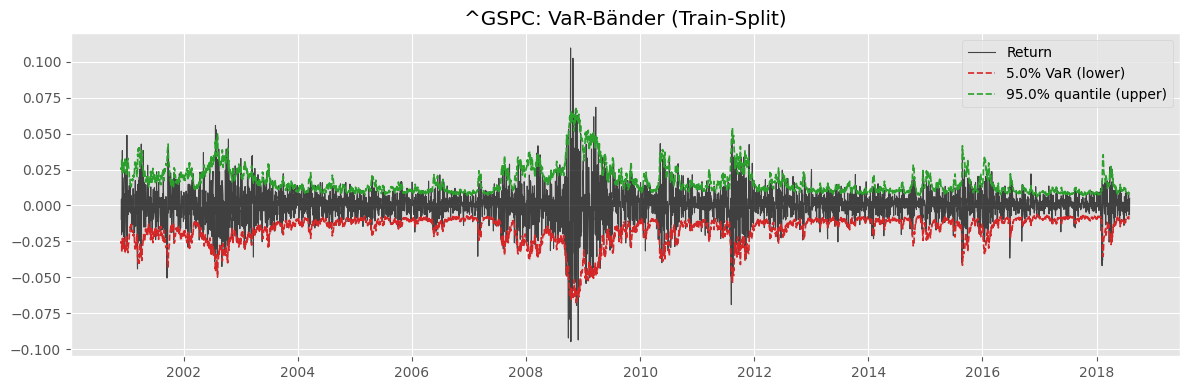

^GSPC: hit rate = 5.655% (target 5.000%)


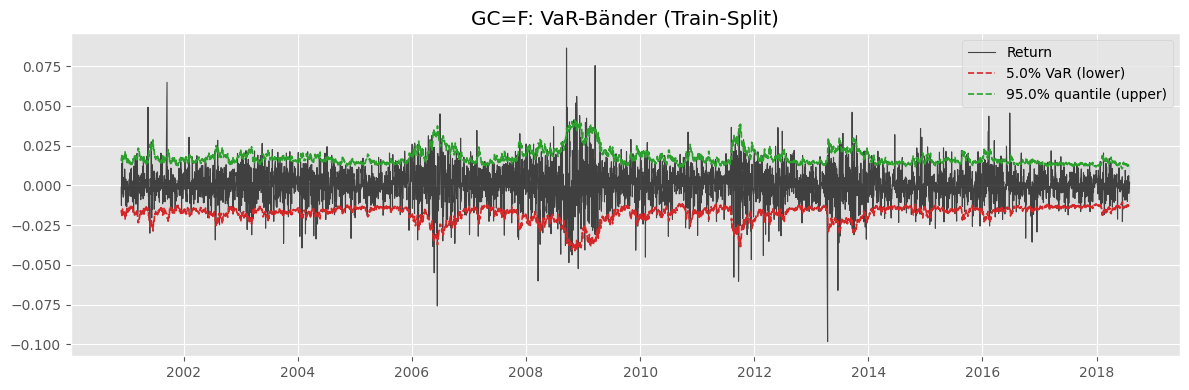

GC=F: hit rate = 4.660% (target 5.000%)


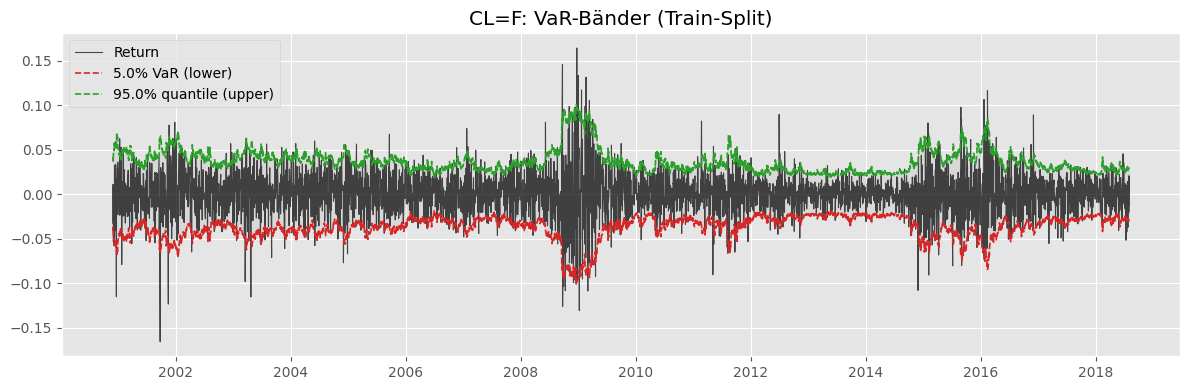

CL=F: hit rate = 4.705% (target 5.000%)


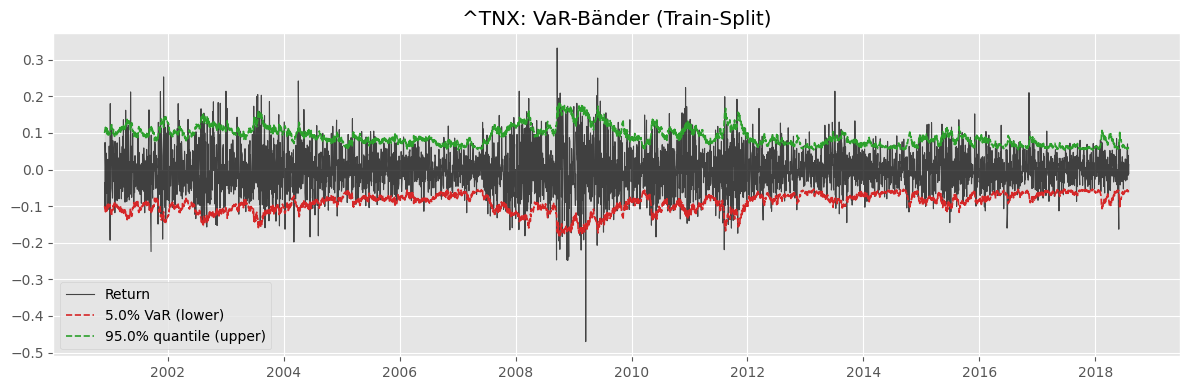

^TNX: hit rate = 4.230% (target 5.000%)


In [178]:
plot_var(alpha=0.05, lookback=lookback, cols=macro_tickers, view="Train-Split", df=train_df, pred_vol=sigma_train_real)

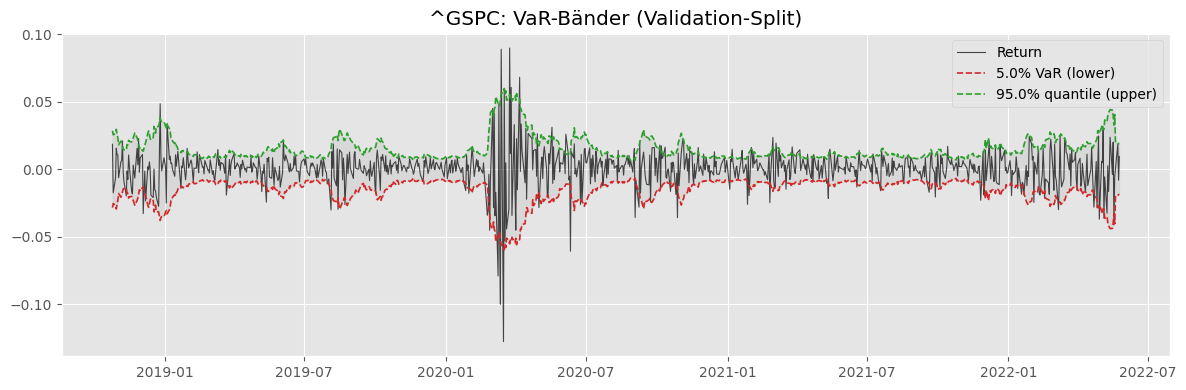

^GSPC: hit rate = 7.778% (target 5.000%)


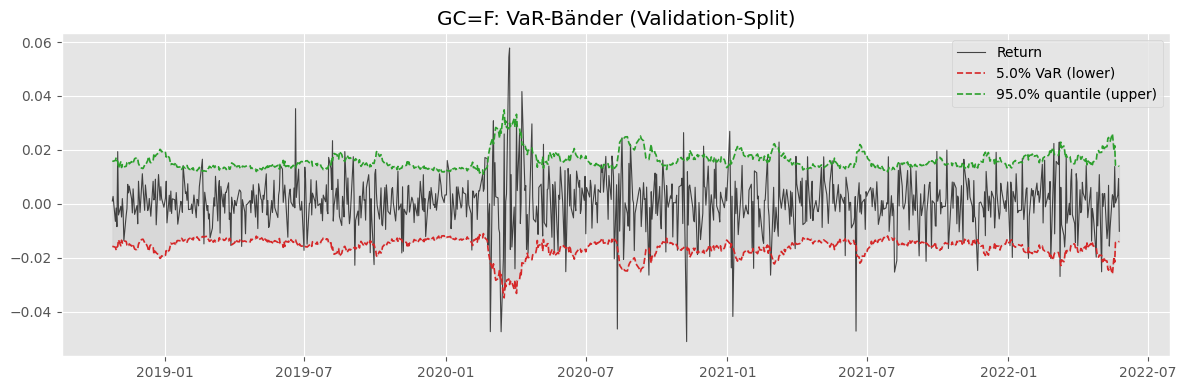

GC=F: hit rate = 5.111% (target 5.000%)


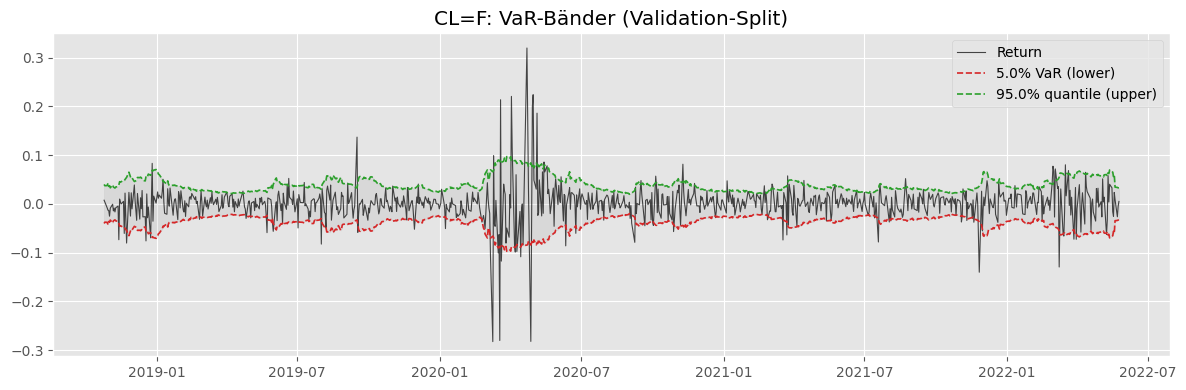

CL=F: hit rate = 7.222% (target 5.000%)


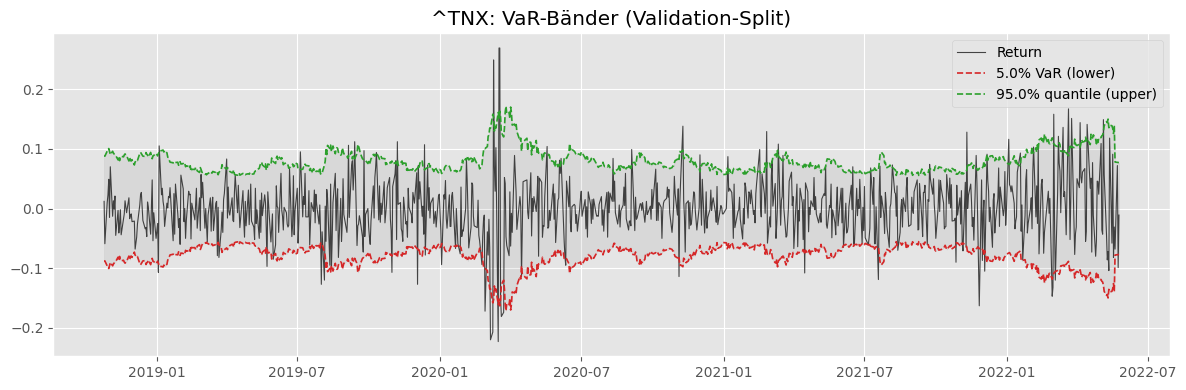

^TNX: hit rate = 4.444% (target 5.000%)


In [179]:
plot_var(alpha=0.05, lookback=lookback, cols=macro_tickers, view="Validation-Split", df=val_df, pred_vol=sigma_val_real)

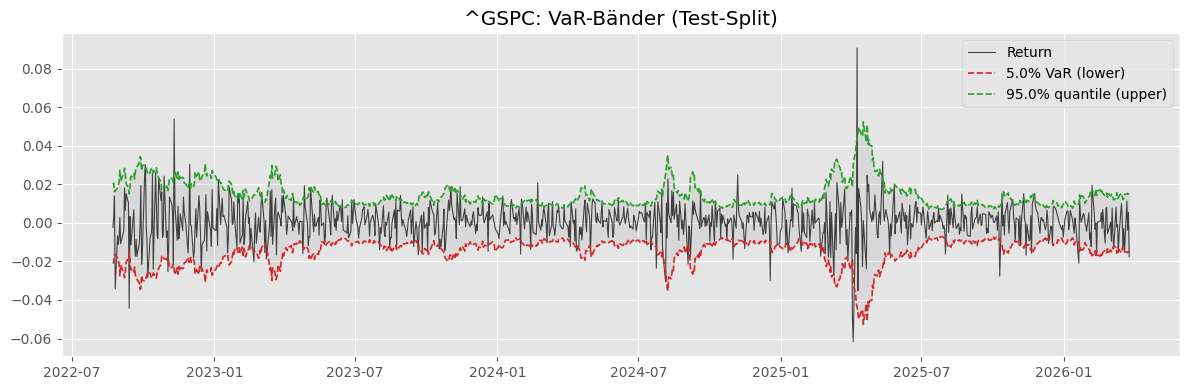

^GSPC: hit rate = 7.103% (target 5.000%)


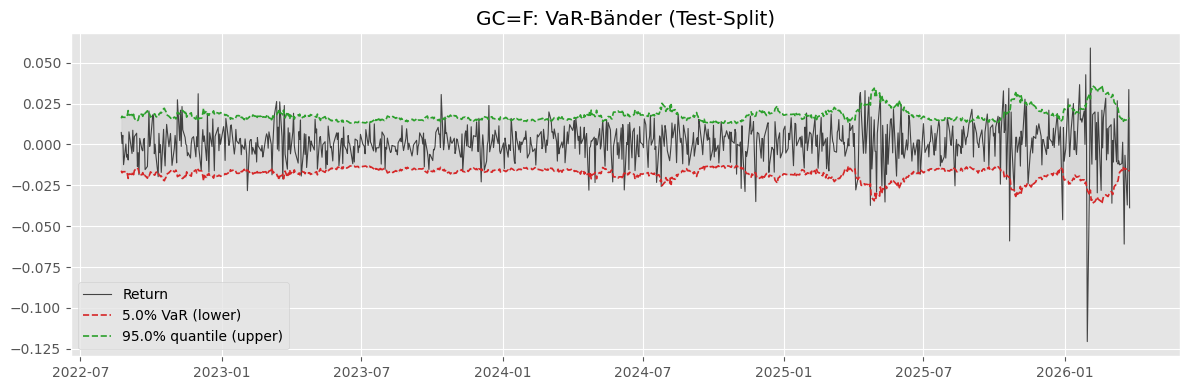

GC=F: hit rate = 3.885% (target 5.000%)


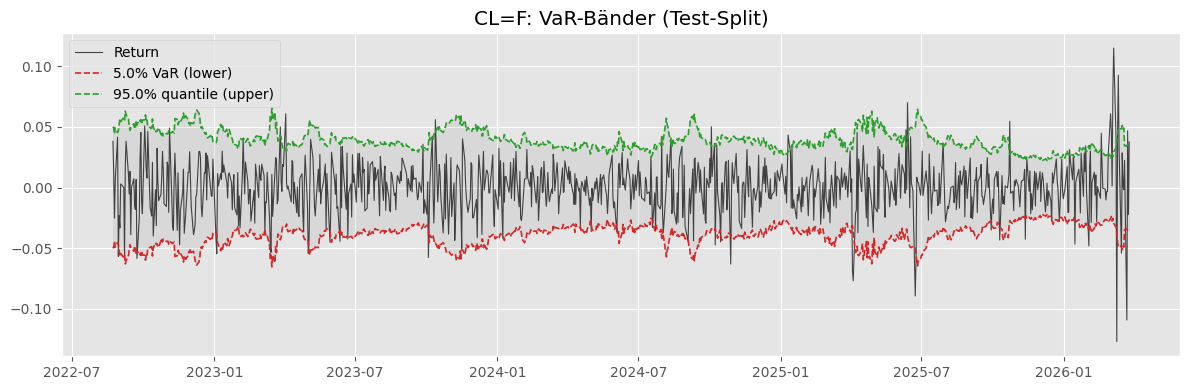

CL=F: hit rate = 3.774% (target 5.000%)


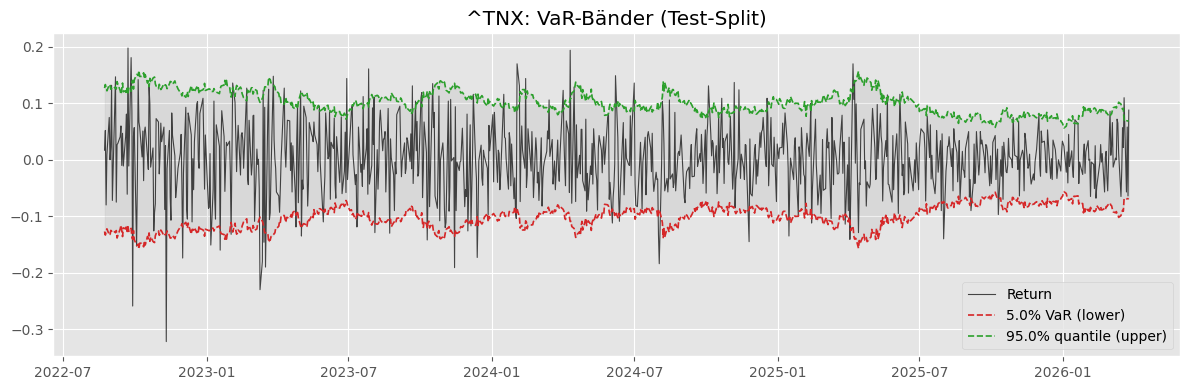

^TNX: hit rate = 4.218% (target 5.000%)


In [180]:
plot_var(alpha=0.05, lookback=lookback, cols=macro_tickers, view="Test-Split", df=test_df, pred_vol=sigma_test_real)

In [181]:
train_df.shape, val_df.shape, test_df.shape

((4481, 14), (960, 14), (961, 14))

# Portfolio Berechnungen

Portfolio Weights & Portfolio Return $r_{p,t} = w^\top \cdot r_t$

$w = (w_1, w_2, \dots, w_n)^\top$ mit $\sum_i^n w_i = 1$

Portfolio Variance:

$\sigma^2_{p,t} = w^\top \Sigma_t w$


In [182]:
w = torch.tensor([0.25, 0.25, 0.25, 0.25], dtype=torch.float32).to(device)  # gleichgewichtetes Portfolio

In [183]:
#w = torch.tensor([0.5, 0.4, 0.1])

In [184]:
w.shape

torch.Size([4])

In [185]:
logret.shape

(6402, 4)

In [186]:
torch.tensor(logret.values).shape

torch.Size([6402, 4])

In [187]:
logret_tensor = torch.tensor(logret.values, dtype=torch.float32, device=w.device)

In [188]:
w.shape

torch.Size([4])

In [189]:
logret_tensor.shape

torch.Size([6402, 4])

In [190]:
portfolio_logrets = (w * logret_tensor).sum(dim=1)

In [191]:
portfolio_logrets.shape

torch.Size([6402])

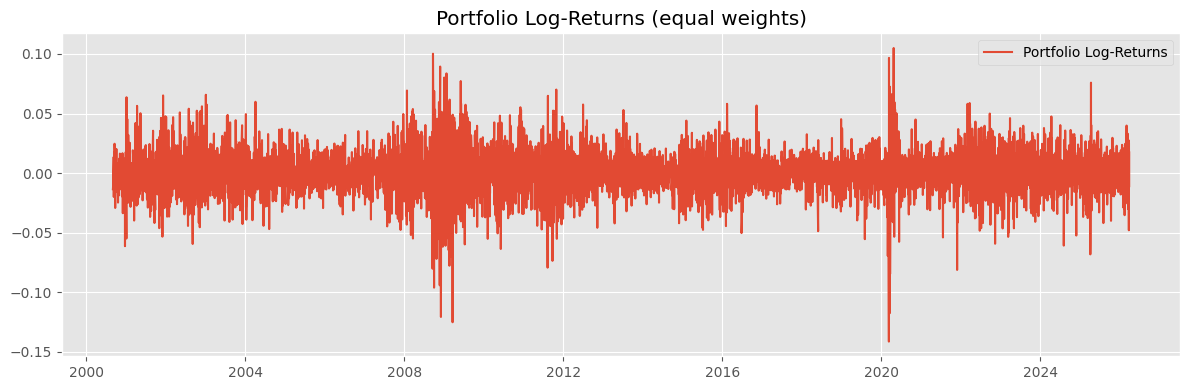

In [192]:
portfolio_logrets_np = portfolio_logrets.detach().cpu().numpy()
plt.figure(figsize=(12, 4))
plt.plot(logret.index, portfolio_logrets_np, label="Portfolio Log-Returns")
plt.title("Portfolio Log-Returns (equal weights)")
plt.legend()
plt.tight_layout()
plt.show()

In [193]:
#w = np.array([0.5, 0.4, 0.1], dtype=np.float32)
#w

In [194]:
def calc_portfolio_variance(df_split, sigma_split, cols, lookback, w):
    idx = df_split.index[lookback:]
    r = df_split.loc[idx, cols].values  # (N-lookback, d)
    r_p = (w*r).sum(axis=1)  # (N-lookback,) Portfolio-Logreturns
    tmp = sigma_split @ w          # (T, d)  = Σ_t w
    var_p = (w * tmp).sum(axis=1) # (1,) = w^T (Σ_t w) Portfolio-Varianz pro t
    vol_p = np.sqrt(var_p)
    
    return idx, r_p, var_p, vol_p

## LSTM mit Normal Loss

In [195]:
w_np = w.detach().cpu().numpy()

In [93]:
sigma_train_real.shape

NameError: name 'sigma_train_real' is not defined

In [196]:
idx_test, rp_test, varp_test, volp_test = calc_portfolio_variance(
    test_df, sigma_test_real, macro_tickers, lookback, w_np
)

idx_val, rp_val, varp_val, volp_val = calc_portfolio_variance(
    val_df, sigma_val_real, macro_tickers, lookback, w_np
)

idx_train, rp_train, varp_train, volp_train = calc_portfolio_variance(
    train_df, sigma_train_real, macro_tickers, lookback, w_np
)

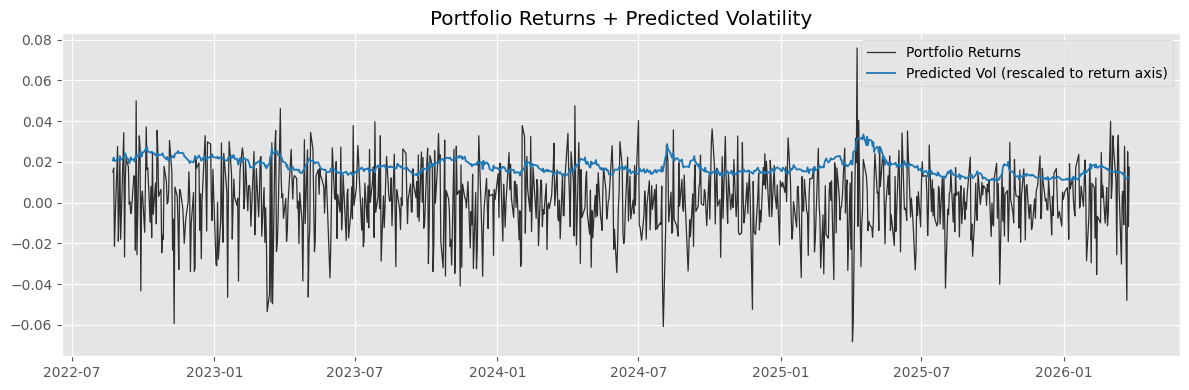

In [197]:
r = np.asarray(rp_test, dtype=float)
v = np.asarray(volp_test, dtype=float)

plt.figure(figsize=(12, 4))
plt.plot(idx_test, r, label="Portfolio Returns", color="black", lw=0.9, alpha=0.8)
plt.plot(idx_test, v, label="Predicted Vol (rescaled to return axis)", color="tab:blue", lw=1.3)
plt.title("Portfolio Returns + Predicted Volatility")
plt.legend()
plt.tight_layout()
plt.show()

In [198]:
def make_portfolio_df(idx, rp, varp, volp):
    return pd.DataFrame(
        {
            "r_p": np.asarray(rp, dtype=float),
            "var_p": np.asarray(varp, dtype=float),
            "vol_p": np.asarray(volp, dtype=float),
        },
        index=idx,
    )

In [199]:
portfolio_test = make_portfolio_df(idx_test, rp_test, varp_test, volp_test)
portfolio_val = make_portfolio_df(idx_val, rp_val, varp_val, volp_val)
portfolio_train = make_portfolio_df(idx_train, rp_train, varp_train, volp_train)

In [200]:
test_df.columns

Index(['^GSPC', 'GC=F', 'CL=F', '^TNX', 'cross_1', 'cross_2', 'cross_3',
       'cross_4', 'cross_5', 'cross_6', 'cross_7', 'cross_8', 'cross_9',
       'cross_10'],
      dtype='object')

In [201]:
macro_tickers

['^GSPC', 'GC=F', 'CL=F', '^TNX']

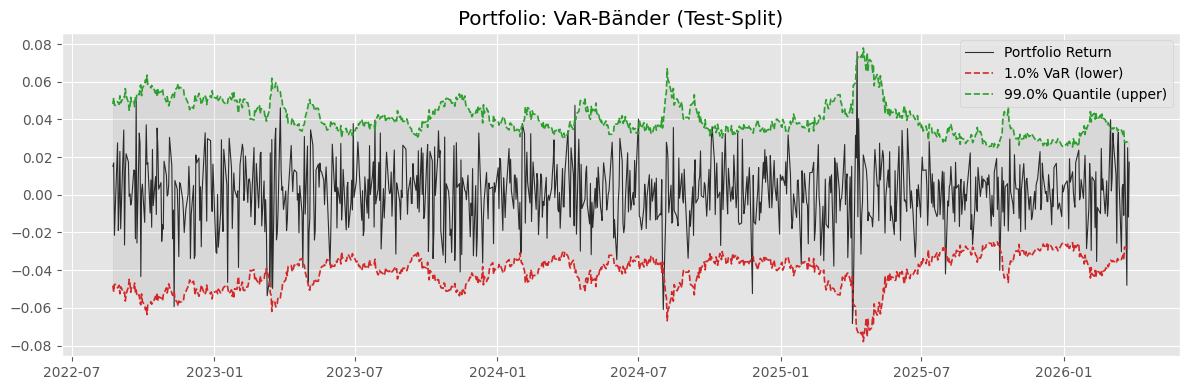

Portfolio hit rate = 1.332% (target 1.000%)


In [202]:
plot_var(alpha=0.01, lookback=lookback, view="Test-Split", portfolio=True, portfolio_df=portfolio_test)

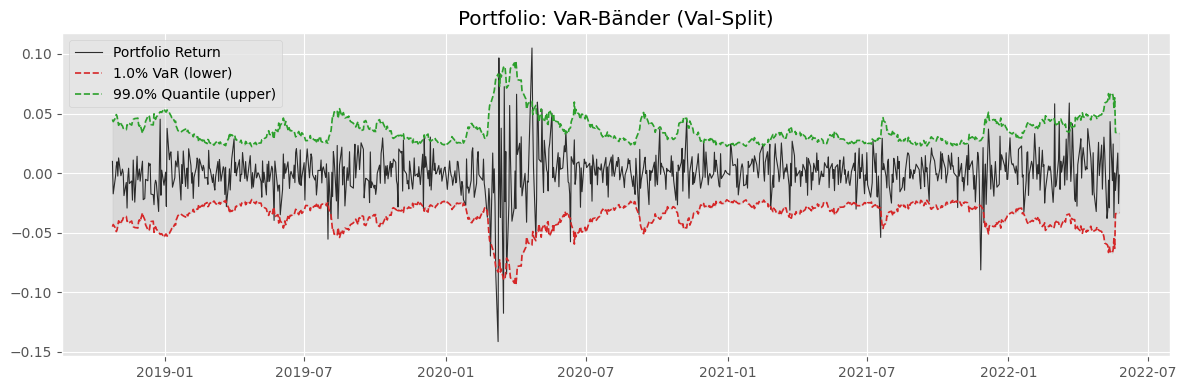

Portfolio hit rate = 2.000% (target 1.000%)


In [203]:
plot_var(alpha=0.01, lookback=lookback, view="Val-Split", portfolio=True, portfolio_df=portfolio_val)

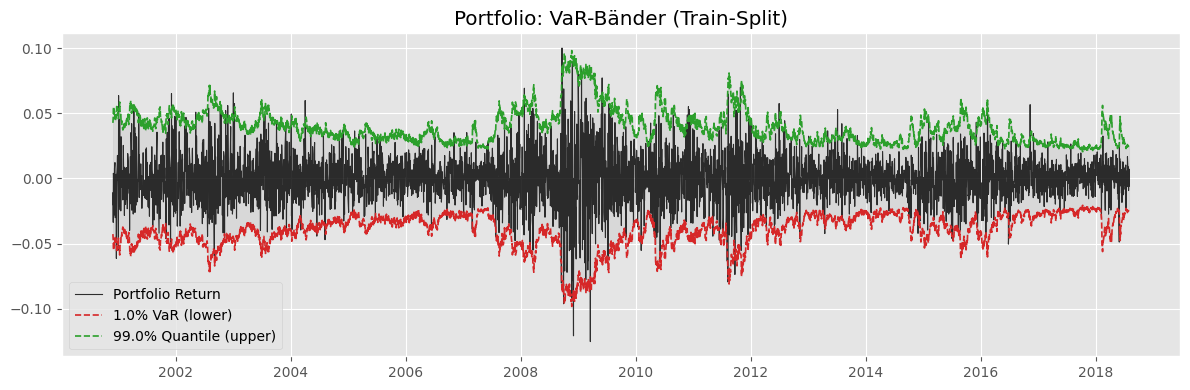

Portfolio hit rate = 1.108% (target 1.000%)


In [204]:
plot_var(alpha=0.01, lookback=lookback, view="Train-Split", portfolio=True, portfolio_df=portfolio_train)

## LSTM mit Student-t Loss

### Training

Modell mit Studen-t-Verteilung

In [205]:
loss_kwargs = {"nu": 5.0}  # vieleicht mit trainieren?

In [206]:
k = len(macro_tickers)*(len(macro_tickers)+1)//2 # Anzahl an Cross Returns, die zusätzlich zu den normalen Returns als Input-Features für die Kovarianzmodellierung genutzt werden

cov_model_t = LSTMCovariance(input_size=(len(macro_tickers)+k), n_assets=len(macro_tickers), hidden_size=64, num_layers=2, dropout=0.2)
cov_model_t, hist_t = train_covariance_model(
    cov_model_t,
    vol_train_loader,
    vol_val_loader,
    loss_fn=student_nll,
    loss_kwargs=loss_kwargs,
    epochs=500,
    lr=1e-4,
    plateau_patience=20,
    device=device,
    scheduler_type="cosine",  # oder "cosine"
)

Epoch 001 | train NLL 5.338018 | val NLL 5.333765 | lr 1.00e-04
Epoch 002 | train NLL 5.240634 | val NLL 5.281600 | lr 1.00e-04
Epoch 003 | train NLL 5.180820 | val NLL 5.266225 | lr 1.00e-04
Epoch 004 | train NLL 5.150835 | val NLL 5.250522 | lr 1.00e-04
Epoch 005 | train NLL 5.122099 | val NLL 5.227518 | lr 1.00e-04
Epoch 006 | train NLL 5.094721 | val NLL 5.197216 | lr 1.00e-04
Epoch 007 | train NLL 5.053148 | val NLL 5.165315 | lr 1.00e-04
Epoch 008 | train NLL 5.024104 | val NLL 5.128927 | lr 9.99e-05
Epoch 009 | train NLL 5.003895 | val NLL 5.111404 | lr 9.99e-05
Epoch 010 | train NLL 4.976093 | val NLL 5.087353 | lr 9.99e-05
Epoch 011 | train NLL 4.963487 | val NLL 5.071515 | lr 9.99e-05
Epoch 012 | train NLL 4.946138 | val NLL 5.051326 | lr 9.99e-05
Epoch 013 | train NLL 4.927513 | val NLL 5.033763 | lr 9.98e-05
Epoch 014 | train NLL 4.916613 | val NLL 5.029912 | lr 9.98e-05
Epoch 015 | train NLL 4.908971 | val NLL 5.008934 | lr 9.98e-05
Epoch 016 | train NLL 4.893939 | val NLL

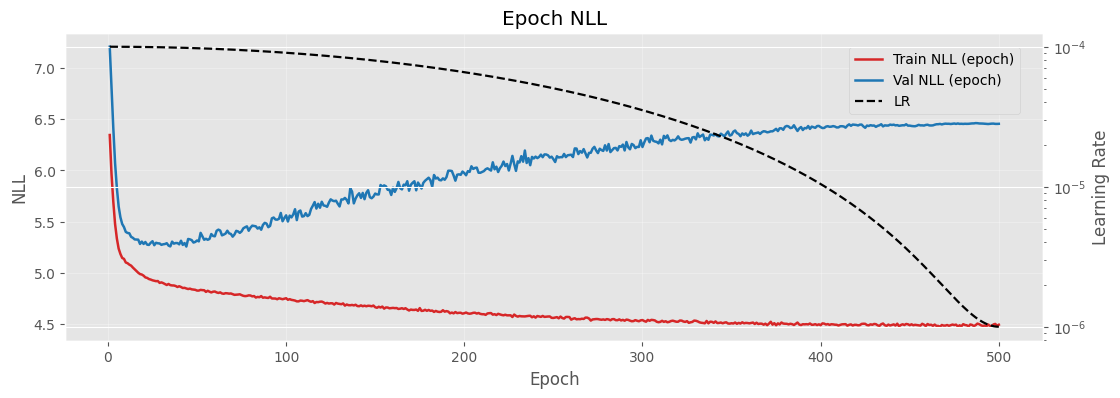

In [207]:
plot_loss(hist)

In [208]:
sigma_val_scaled_t, y_val_scale_t = predict_sigma(cov_model_t, vol_val_loader, device=device)
sigma_test_scaled_t, y_test_scaled_t = predict_sigma(cov_model_t, vol_test_loader, device=device)

sigma_val_real_t = scale_back(sigma_val_scaled_t, sigma=sigma, feature_cols=macro_tickers)
sigma_test_real_t = scale_back(sigma_test_scaled_t, sigma=sigma, feature_cols=macro_tickers)

In [209]:
vol_train_eval_loader = DataLoader(vol_train_ds, batch_size=batchsize, shuffle=False)
sigma_train_scaled_t, y_train_scaled_t = predict_sigma(cov_model_t, vol_train_eval_loader, device=device)
sigma_train_real_t = scale_back(sigma_train_scaled_t, sigma=sigma, feature_cols=macro_tickers)

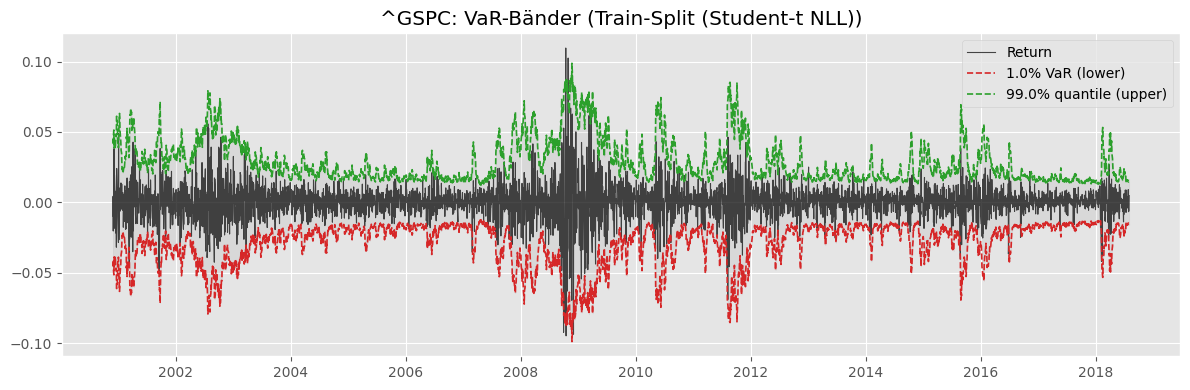

^GSPC: hit rate = 0.814% (target 1.000%)


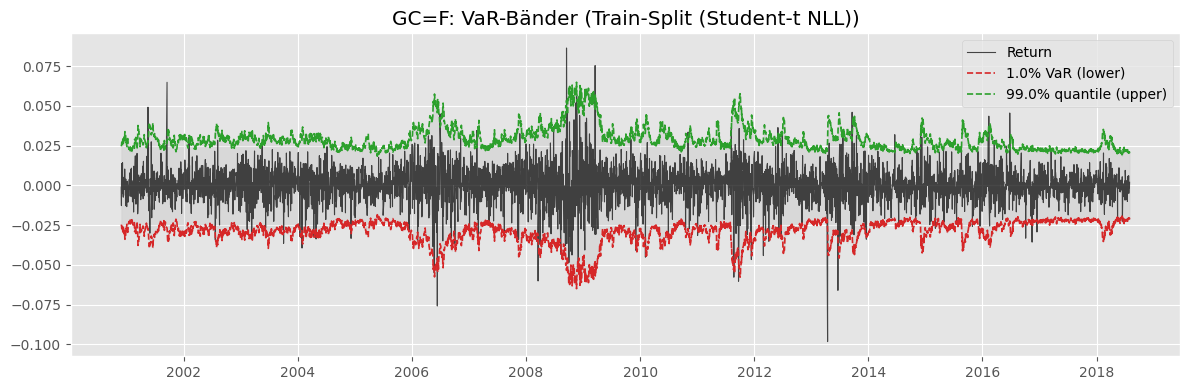

GC=F: hit rate = 0.905% (target 1.000%)


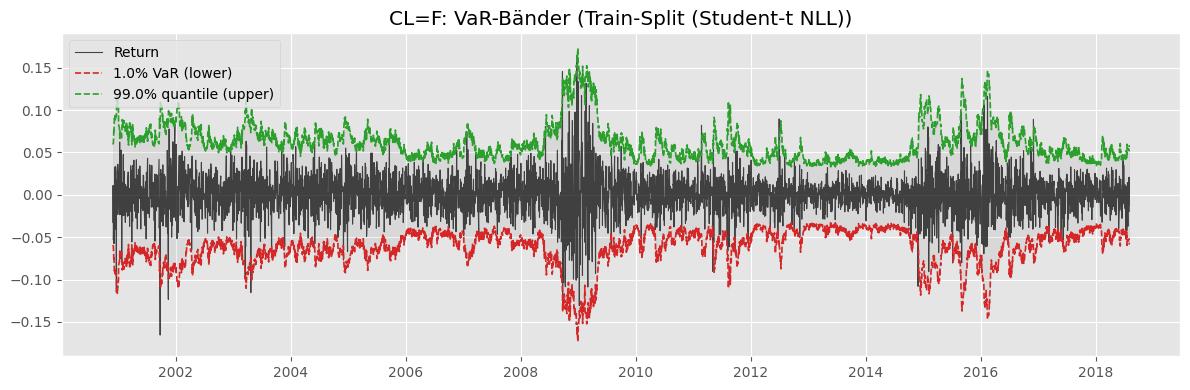

CL=F: hit rate = 0.565% (target 1.000%)


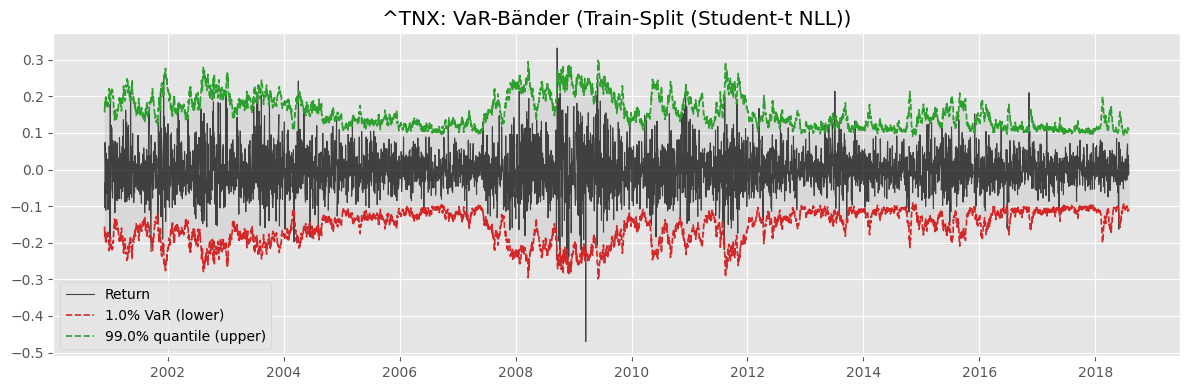

^TNX: hit rate = 0.430% (target 1.000%)


In [210]:
plot_var(alpha=0.01, lookback=lookback, cols=macro_tickers, view="Train-Split (Student-t NLL)", df=train_df, pred_vol=sigma_train_real_t, loss_fn=student_nll, loss_kwargs=loss_kwargs)

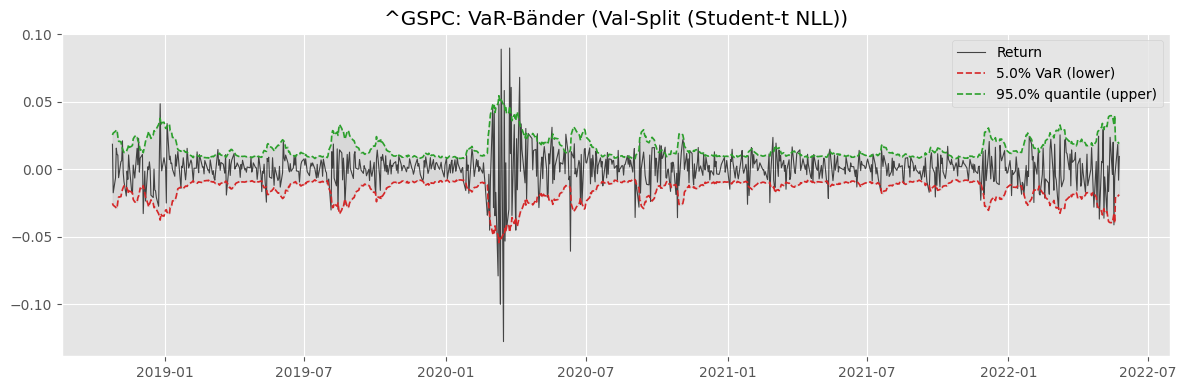

^GSPC: hit rate = 7.333% (target 5.000%)


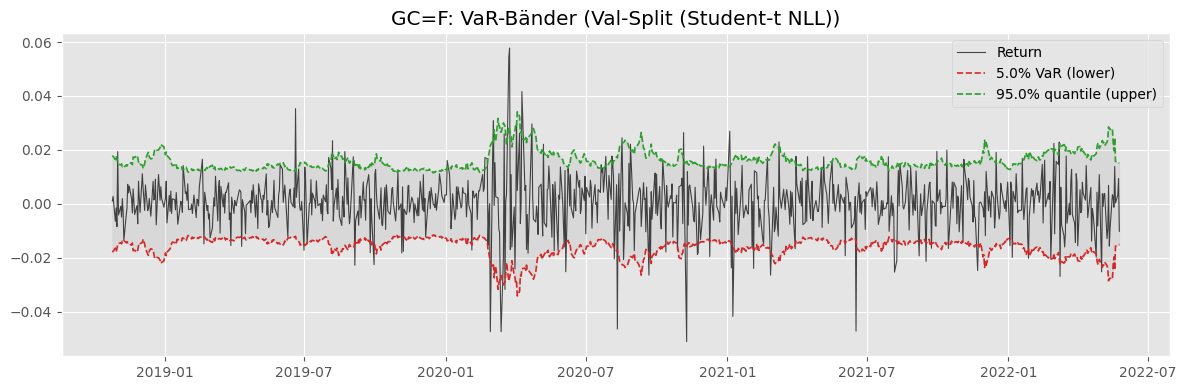

GC=F: hit rate = 5.333% (target 5.000%)


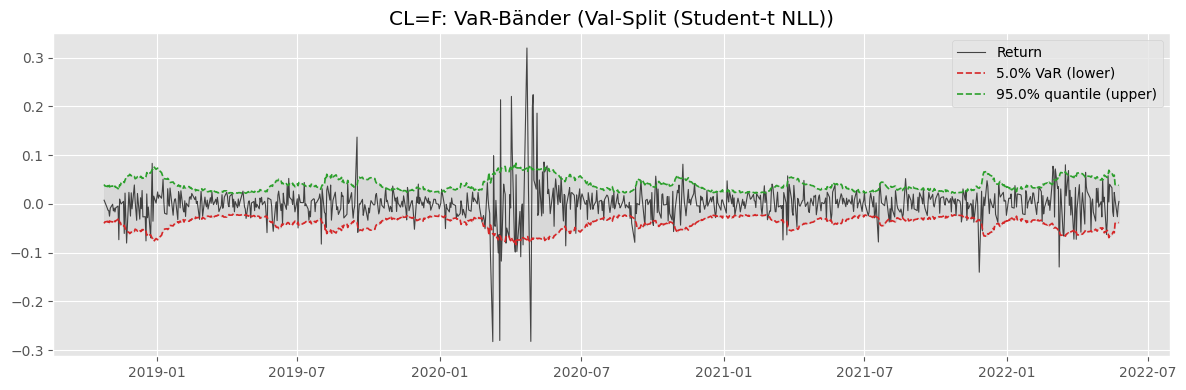

CL=F: hit rate = 7.222% (target 5.000%)


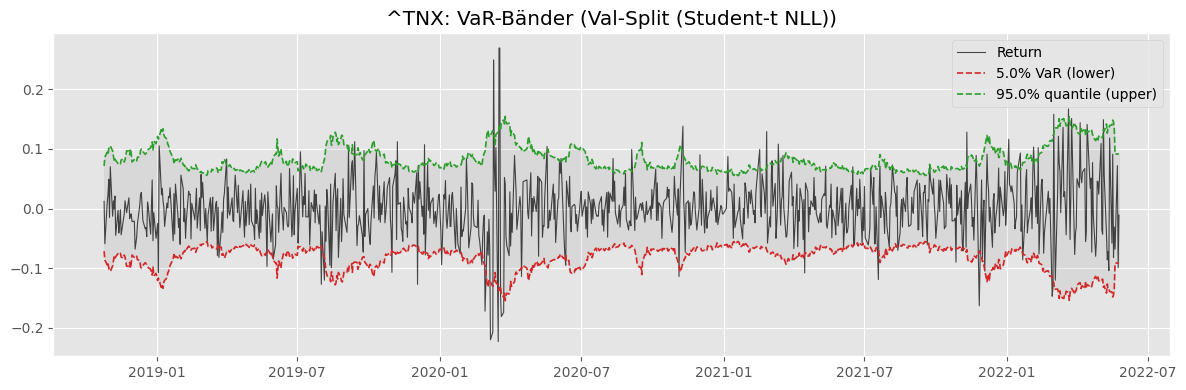

^TNX: hit rate = 3.667% (target 5.000%)


In [211]:
plot_var(alpha=0.05, lookback=lookback, cols=macro_tickers, view="Val-Split (Student-t NLL)", df=val_df, pred_vol=sigma_val_real_t, loss_fn=student_nll, loss_kwargs=loss_kwargs)

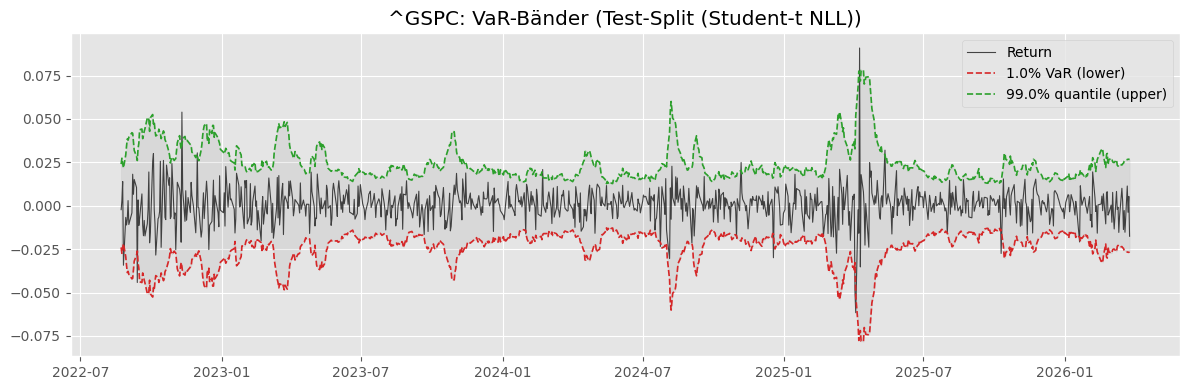

^GSPC: hit rate = 1.332% (target 1.000%)


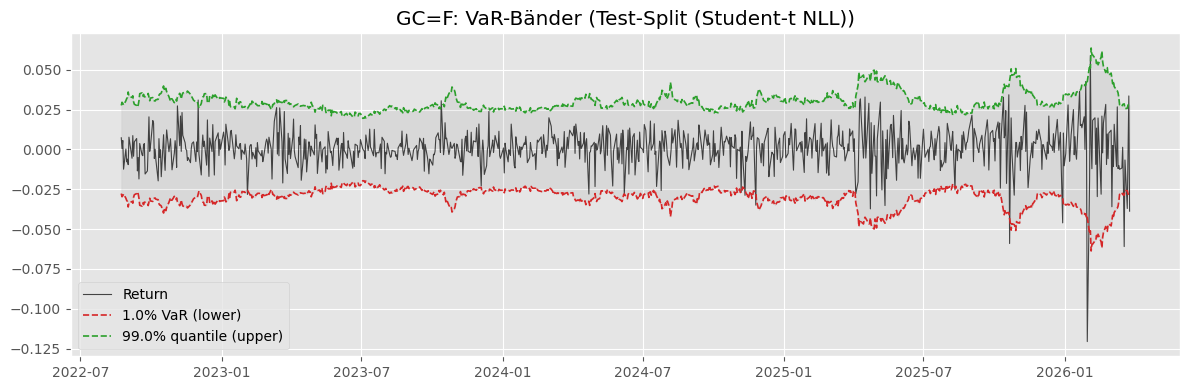

GC=F: hit rate = 1.221% (target 1.000%)


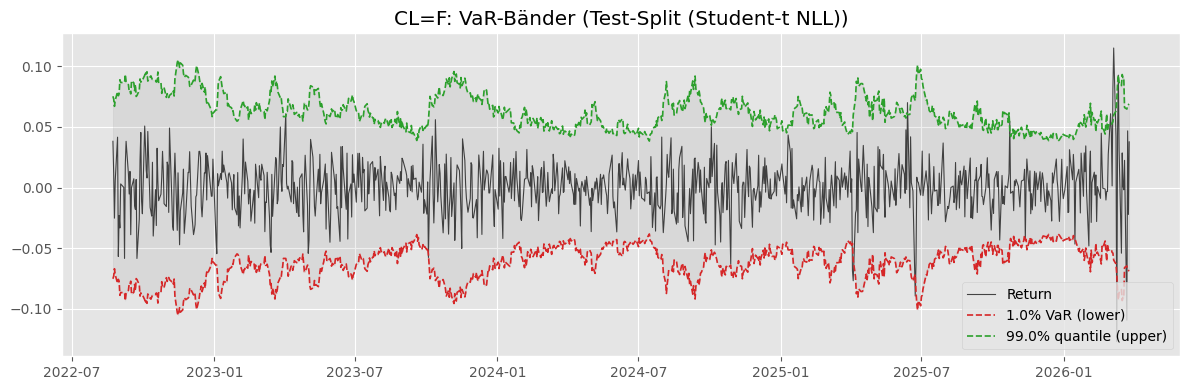

CL=F: hit rate = 0.777% (target 1.000%)


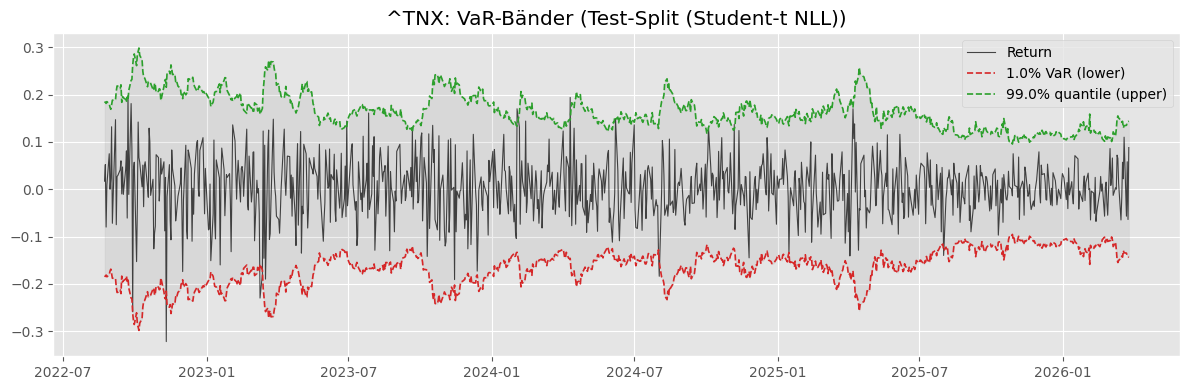

^TNX: hit rate = 0.777% (target 1.000%)


In [212]:
plot_var(alpha=0.01, lookback=lookback, cols=macro_tickers, view="Test-Split (Student-t NLL)", df=test_df, pred_vol=sigma_test_real_t, loss_fn=student_nll, loss_kwargs=loss_kwargs)

### Portfolio Returns

- Hier müssten jetzt noch mal die Portfolio Returns & Volas mit ```make_portfolio_df``` berechnet werden für Student-t Verteilung!

In [213]:
idx_test_t, rp_test_t, varp_test_t, volp_test_t = calc_portfolio_variance(
    test_df, sigma_test_real_t, macro_tickers, lookback, w_np
)

idx_val_t, rp_val_t, varp_val_t, volp_val_t = calc_portfolio_variance(
    val_df, sigma_val_real_t, macro_tickers, lookback, w_np
)

idx_train_t, rp_train_t, varp_train_t, volp_train_t = calc_portfolio_variance(
    train_df, sigma_train_real_t, macro_tickers, lookback, w_np
)

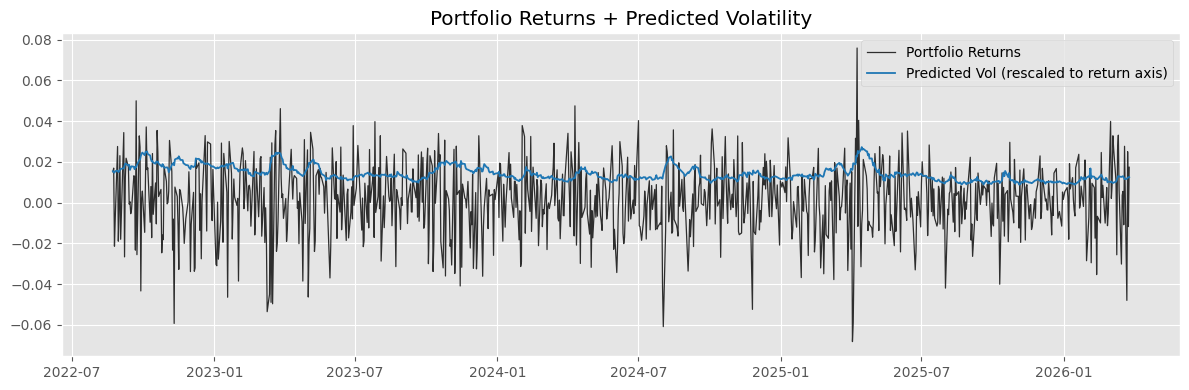

In [214]:
r = np.asarray(rp_test_t, dtype=float)
v = np.asarray(volp_test_t, dtype=float)

plt.figure(figsize=(12, 4))
plt.plot(idx_test, r, label="Portfolio Returns", color="black", lw=0.9, alpha=0.8)
plt.plot(idx_test, v, label="Predicted Vol (rescaled to return axis)", color="tab:blue", lw=1.3)
plt.title("Portfolio Returns + Predicted Volatility")
plt.legend()
plt.tight_layout()
plt.show()

In [215]:
portfolio_test_t = make_portfolio_df(idx_test_t, rp_test_t, varp_test_t, volp_test_t)
portfolio_val_t = make_portfolio_df(idx_val_t, rp_val_t, varp_val_t, volp_val_t)
portfolio_train_t = make_portfolio_df(idx_train_t, rp_train_t, varp_train_t, volp_train_t)

Modell mit skewed Studen-t-Verteilung

## Filtered Historical Simulation

- bisher FHS nur mit Normal Volas

In [216]:
from risk_metrics import fhs_var_es

In [230]:
alpha = 0.01
window = 500  # z.B. 250/500/1000 testen

### Normal Loss (Portfolio)

In [231]:
z_train = portfolio_train["r_p"].values / np.clip(portfolio_train["vol_p"].values, 1e-12, None) # clip sichert nur nach unten ab (0 division)
z_val = portfolio_val["r_p"].values / np.clip(portfolio_val["vol_p"].values, 1e-12, None)
z_test = portfolio_test["r_p"].values / np.clip(portfolio_test["vol_p"].values, 1e-12, None)
z_train_val =np.concatenate([z_train, z_val])


var_fhs_test, es_fhs_test, hits_test = fhs_var_es(
    z_hist_init=z_train_val, # nimmt die letzen #window Werte als Historie
    r_oos=portfolio_test["r_p"].values,
    vol_oos=portfolio_test["vol_p"].values,
    alpha=alpha,
    window=window
)

hit_rate_test = hits_test.mean()
print(f"FHS Test hit rate = {hit_rate_test:.3%} (target {alpha:.3%})")

FHS Test hit rate = 0.999% (target 1.000%)


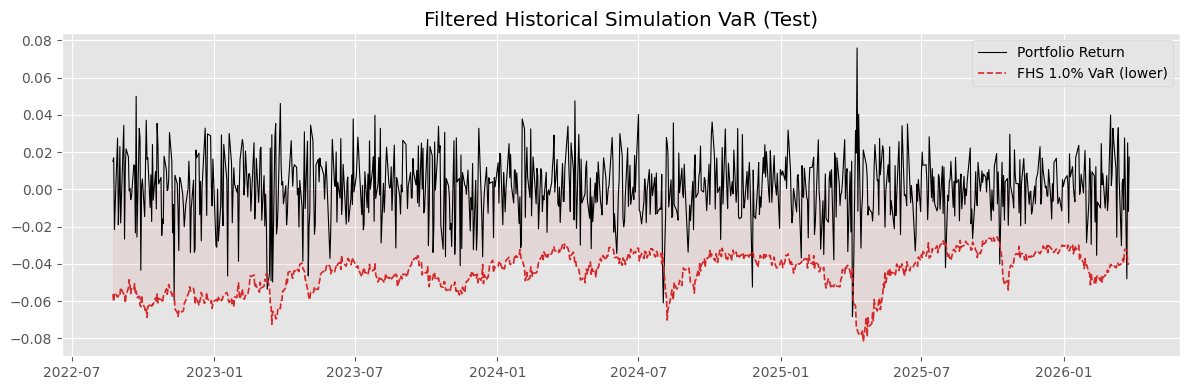

In [232]:
plt.figure(figsize=(12,4))
plt.plot(portfolio_test.index, portfolio_test["r_p"].values, color="black", lw=0.8, label="Portfolio Return")
plt.plot(portfolio_test.index, var_fhs_test, "--", color="tab:red", lw=1.2, label=f"FHS {alpha:.1%} VaR (lower)")
plt.fill_between(portfolio_test.index, var_fhs_test, np.zeros_like(var_fhs_test), color="tab:red", alpha=0.08)
plt.title("Filtered Historical Simulation VaR (Test)")
plt.legend()
plt.tight_layout()
plt.show()

- Falls FHS auf train genutzt werden soll, muss zuvor ein z_train_burn_in genutzt werden wo zb die ersten 500 z_t aus train genutzt werden für die historie und von dort aus wird dann der VaR rollierend berechnet!

In [233]:
z_train_burn_in = z_train[:window]

In [234]:
var_fhs_train, es_fhs_train, hit_train = fhs_var_es(
    z_hist_init=z_train_burn_in, # custom burn-in für Historie nötig
    r_oos=portfolio_train["r_p"][window:].values,
    vol_oos=portfolio_train["vol_p"][window:].values,
    alpha=alpha,
    window=window
)

hit_rate_train = hit_train.mean()
print(f"FHS Train hit rate = {hit_rate_train:.3%} (target {alpha:.3%})")

FHS Train hit rate = 1.250% (target 1.000%)


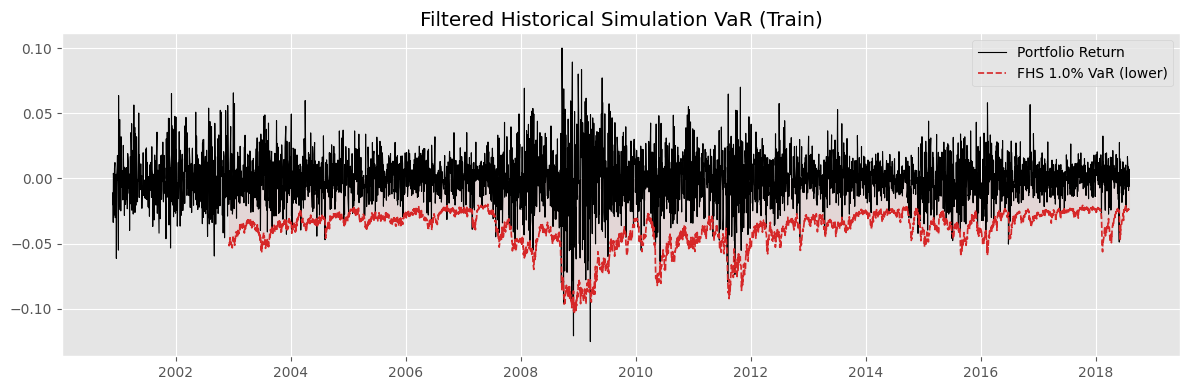

In [235]:
plt.figure(figsize=(12,4))
plt.plot(portfolio_train.index, portfolio_train["r_p"].values, color="black", lw=0.8, label="Portfolio Return")
plt.plot(portfolio_train[window:].index, var_fhs_train, "--", color="tab:red", lw=1.2, label=f"FHS {alpha:.1%} VaR (lower)")
plt.fill_between(portfolio_train[window:].index, var_fhs_train, np.zeros_like(var_fhs_train), color="tab:red", alpha=0.08)
plt.title("Filtered Historical Simulation VaR (Train)")
plt.legend()
plt.tight_layout()
plt.show()

In [236]:
var_fhs_val, es_fhs_val, hit_val = fhs_var_es(
    z_hist_init=z_train,
    r_oos=portfolio_val["r_p"].values,
    vol_oos=portfolio_val["vol_p"].values,
    alpha=alpha,
    window=window
)

hit_rate_val = hit_val.mean()
print(f"FHS Val hit rate = {hit_rate_val:.3%} (target {alpha:.3%})")

FHS Val hit rate = 1.444% (target 1.000%)


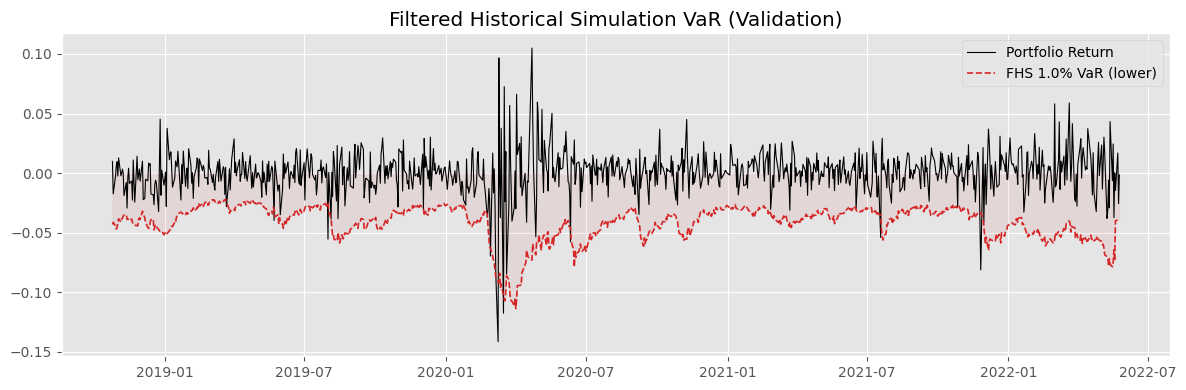

In [237]:
plt.figure(figsize=(12,4))
plt.plot(portfolio_val.index, portfolio_val["r_p"].values, color="black", lw=0.8, label="Portfolio Return")
plt.plot(portfolio_val.index, var_fhs_val, "--", color="tab:red", lw=1.2, label=f"FHS {alpha:.1%} VaR (lower)")
plt.fill_between(portfolio_val.index, var_fhs_val, np.zeros_like(var_fhs_val), color="tab:red", alpha=0.08)
plt.title("Filtered Historical Simulation VaR (Validation)")
plt.legend()
plt.tight_layout()
plt.show()

### Student-t Loss (Portfolio)

In [238]:
z_train_t = portfolio_train_t["r_p"].values / np.clip(portfolio_train_t["vol_p"].values, 1e-12, None) # clip sichert nur nach unten ab (0 division)
z_val_t = portfolio_val_t["r_p"].values / np.clip(portfolio_val_t["vol_p"].values, 1e-12, None)
z_test_t = portfolio_test_t["r_p"].values / np.clip(portfolio_test_t["vol_p"].values, 1e-12, None)
z_train_val_t =np.concatenate([z_train_t, z_val_t])


var_fhs_test_t, es_fhs_test_t, hits_test_t = fhs_var_es(
    z_hist_init=z_train_val_t, # nimmt die letzen #window Werte als Historie
    r_oos=portfolio_test_t["r_p"].values,
    vol_oos=portfolio_test_t["vol_p"].values,
    alpha=alpha,
    window=window
)

hit_rate_test_t = hits_test_t.mean()
print(f"FHS Test hit rate = {hit_rate_test_t:.3%} (target {alpha:.3%})")

FHS Test hit rate = 1.110% (target 1.000%)


# MGARCH-LSTM mit BEKK Kernel Function (Zhao et al. 2024)

$s_{t-1} := \operatorname{vech}(\Sigma_{t-1})$

$$
f_t = \sigma_g\!\left(W_f \varepsilon_{t-1} 
      + U_f s_{t-1} 
      + b_f\right), \\
i_t = \sigma_g\!\left(W_i \varepsilon_{t-1} 
      + U_i s_{t-1} 
      + b_i\right), \\
\tilde c_t = \sigma_c\!\left(W_c \varepsilon_{t-1} 
      + U_c s_{t-1} 
      + b_c\right), \\
c_t = f_t \odot c_{t-1} 
      + i_t \odot \tilde c_t.
$$

The output gate can then be reinterpreted as a BEKK kernel output
$$
o_t := \mathcal{K}_{\text{BEKK}}(\varepsilon_{t-1}, \Sigma_{t-1}; \Theta), \\
\mathcal{K}_{\text{BEKK}} = C C^\top 
      + A^\top \varepsilon_{t-1}\varepsilon_{t-1}^\top A 
      + B^\top \Sigma_{t-1} B.
$$

$$m_t = 1 + \beta \tanh(w_o^\top \tanh(c_t) + b_o)$$

$$\Sigma_t
= o_t \times m_t = 
\underbrace{m_t}_{\text{LSTM}}
\times
\underbrace{
\left(
CC^\top
+
A^\top \varepsilon_{t-1}\varepsilon_{t-1}^\top A
+
B^\top \Sigma_{t-1} B
\right)
}_{\text{BEKK(1,1)}}$$

In [226]:
from bekk_kernel import BEKKCell, BEKKLSTM

- Es müssen neue Dataset & Dataloader angelegt werden, da die MGARCH Kernel Function ein BEKK(1,1) ist. Daher ist der bisherige ```lookback=60``` nicht passend.

In [227]:
loss_kwargs = {"nu": 10.0}

In [229]:
bekk_kernel_lstm = BEKKLSTM(input_size=(len(macro_tickers)+k), n_assets=len(macro_tickers), hidden_size=64, asym=True)
bekk_kernel_lstm, hist_bekk = train_covariance_model(
    bekk_kernel_lstm,
    vol_train_loader,
    vol_val_loader,
    loss_fn=student_nll,
    loss_kwargs=loss_kwargs,
    epochs=500,
    lr=1e-4,
    plateau_patience=20,
    device=device,
    scheduler_type="cosine",  # oder "cosine"
)

Epoch 001 | train NLL 6.007701 | val NLL 5.877650 | lr 1.00e-04
Epoch 002 | train NLL 5.656183 | val NLL 5.623018 | lr 1.00e-04
Epoch 003 | train NLL 5.460557 | val NLL 5.466033 | lr 1.00e-04
Epoch 004 | train NLL 5.340721 | val NLL 5.370499 | lr 1.00e-04
Epoch 005 | train NLL 5.272936 | val NLL 5.315457 | lr 1.00e-04
Epoch 006 | train NLL 5.225950 | val NLL 5.287440 | lr 1.00e-04
Epoch 007 | train NLL 5.208291 | val NLL 5.270220 | lr 1.00e-04
Epoch 008 | train NLL 5.195466 | val NLL 5.257395 | lr 9.99e-05
Epoch 009 | train NLL 5.176454 | val NLL 5.246621 | lr 9.99e-05
Epoch 010 | train NLL 5.166441 | val NLL 5.236174 | lr 9.99e-05
Epoch 011 | train NLL 5.159844 | val NLL 5.226757 | lr 9.99e-05
Epoch 012 | train NLL 5.143385 | val NLL 5.215368 | lr 9.99e-05
Epoch 013 | train NLL 5.134552 | val NLL 5.204342 | lr 9.98e-05
Epoch 014 | train NLL 5.133941 | val NLL 5.190974 | lr 9.98e-05
Epoch 015 | train NLL 5.122311 | val NLL 5.179515 | lr 9.98e-05
Epoch 016 | train NLL 5.111961 | val NLL

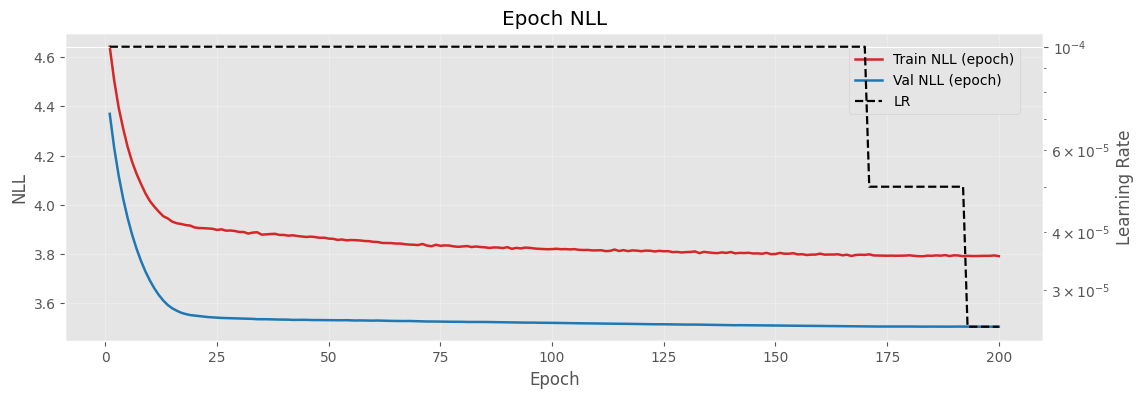

In [ ]:
plot_loss(hist_bekk)

In [240]:
sigma_val_scaled_bekk, y_val_scaled_bekk = predict_sigma(bekk_kernel_lstm, vol_val_loader, device=device)
sigma_val_real_bekk = scale_back(sigma_val_scaled_bekk, sigma=sigma, feature_cols=macro_tickers)

sigma_test_scaled_bekk, y_test_scaled_bekk = predict_sigma(bekk_kernel_lstm, vol_test_loader, device=device)
sigma_test_real_bekk = scale_back(sigma_test_scaled_bekk, sigma=sigma, feature_cols=macro_tickers)


sigma_train_scaled_bekk, y_train_scaled_bekk = predict_sigma(bekk_kernel_lstm, vol_train_eval_loader, device=device)
sigma_train_real_bekk = scale_back(sigma_train_scaled_bekk, sigma=sigma, feature_cols=macro_tickers)

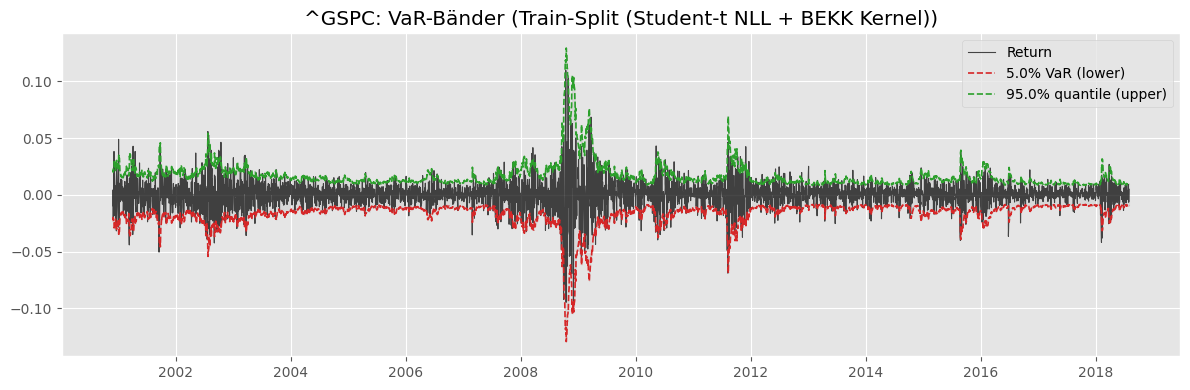

^GSPC: hit rate = 5.180% (target 5.000%)


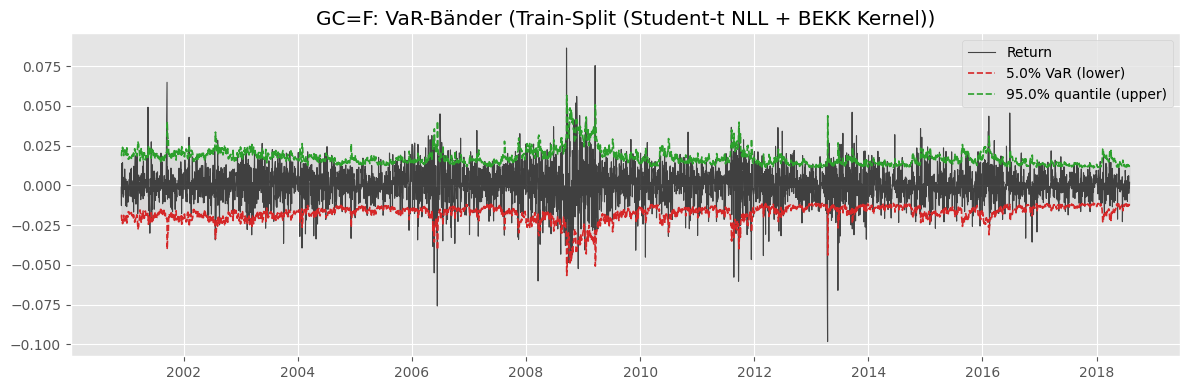

GC=F: hit rate = 5.406% (target 5.000%)


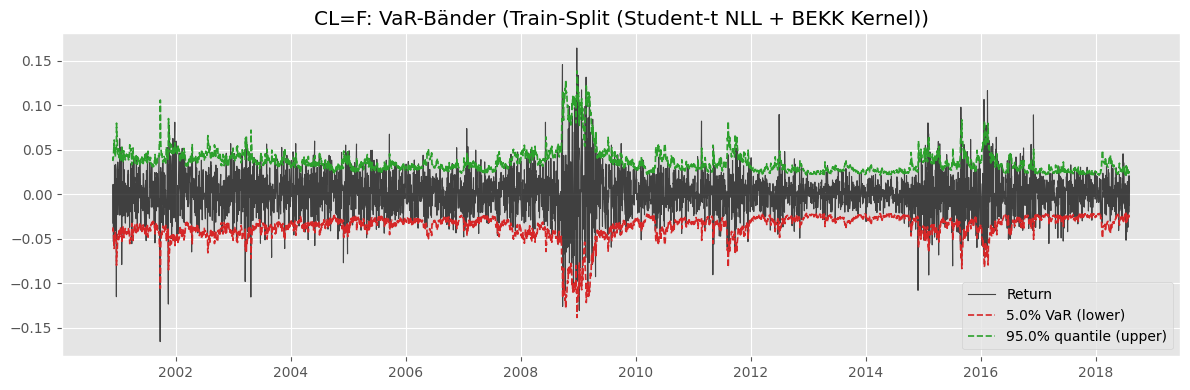

CL=F: hit rate = 5.180% (target 5.000%)


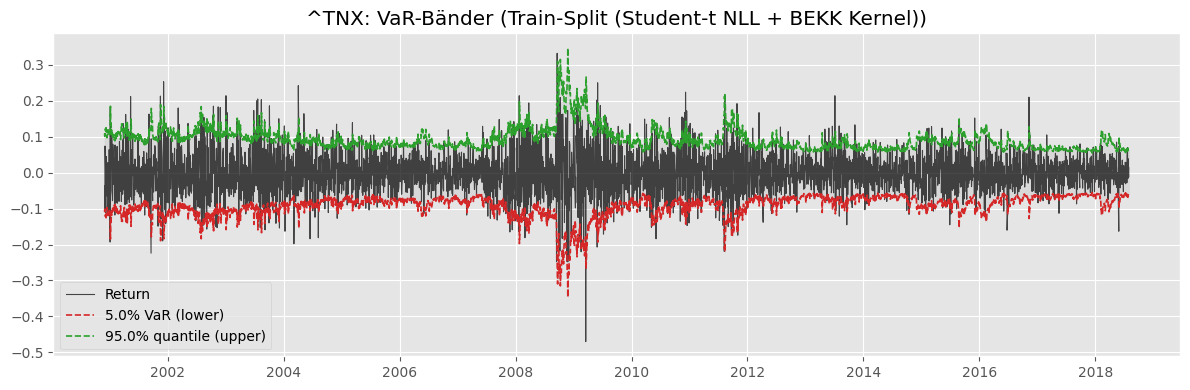

^TNX: hit rate = 4.727% (target 5.000%)


In [241]:
plot_var(alpha=0.05, lookback=lookback, cols=macro_tickers, view="Train-Split (Student-t NLL + BEKK Kernel)", df=train_df, pred_vol=sigma_train_real_bekk, loss_fn=student_nll, loss_kwargs=loss_kwargs)

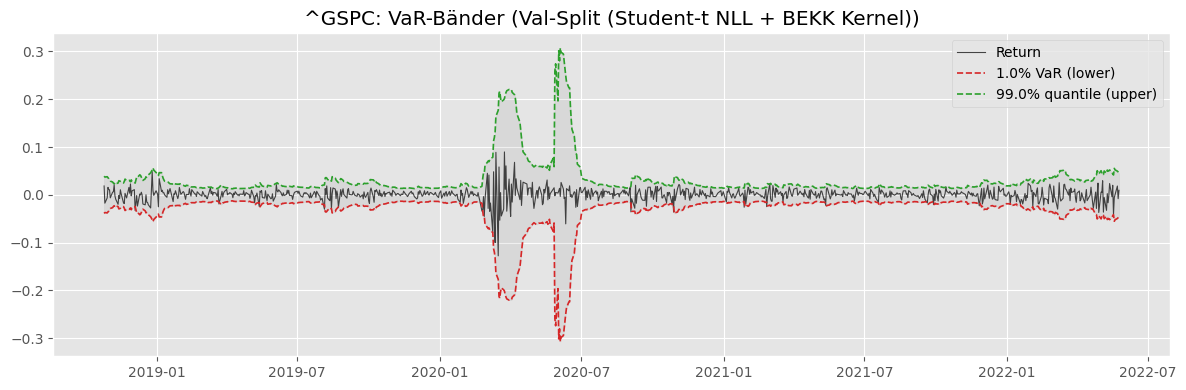

^GSPC: hit rate = 2.333% (target 1.000%)


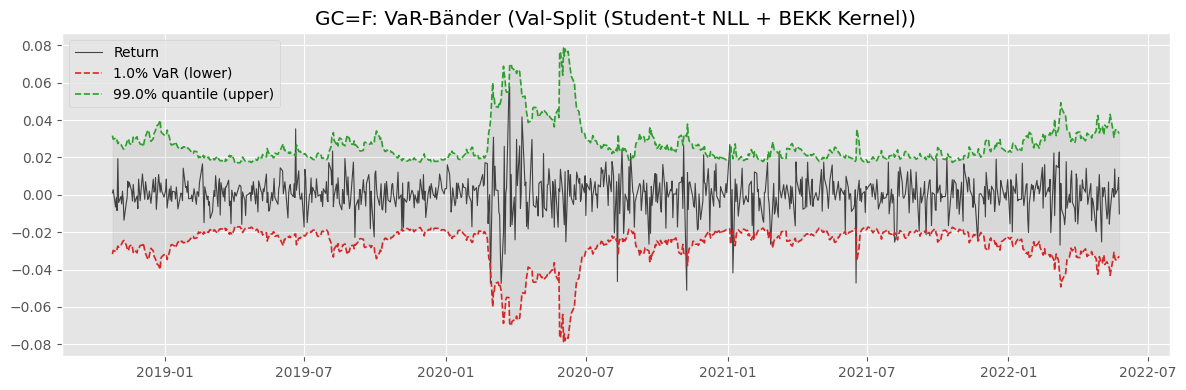

GC=F: hit rate = 1.222% (target 1.000%)


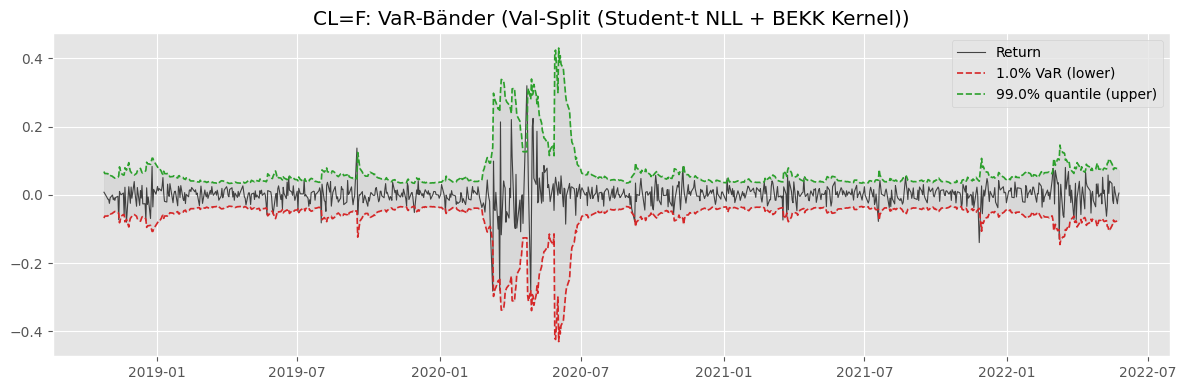

CL=F: hit rate = 2.556% (target 1.000%)


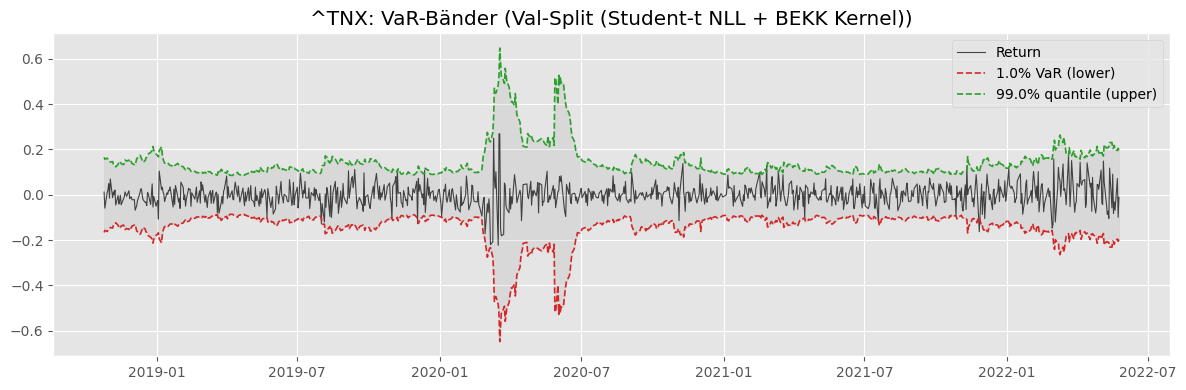

^TNX: hit rate = 0.667% (target 1.000%)


In [242]:
plot_var(alpha=0.01, lookback=lookback, cols=macro_tickers, view="Val-Split (Student-t NLL + BEKK Kernel)", df=val_df, pred_vol=sigma_val_real_bekk, loss_fn=student_nll, loss_kwargs=loss_kwargs)

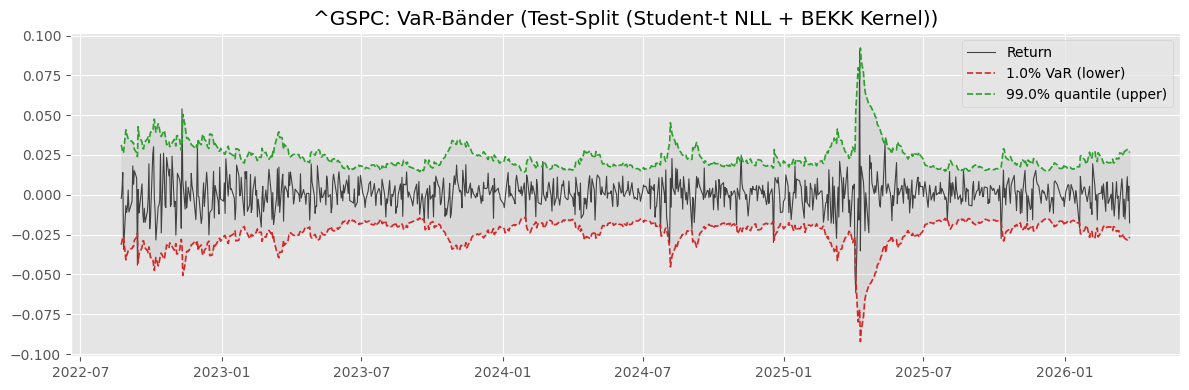

^GSPC: hit rate = 1.221% (target 1.000%)


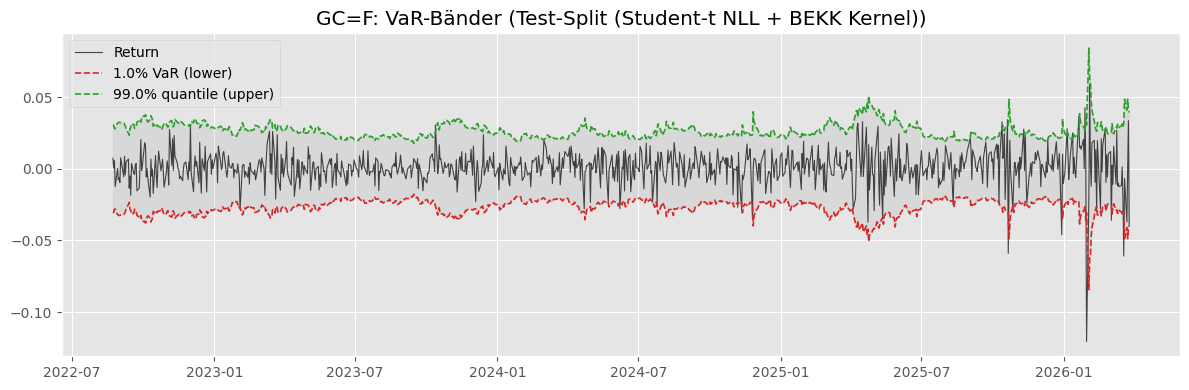

GC=F: hit rate = 1.776% (target 1.000%)


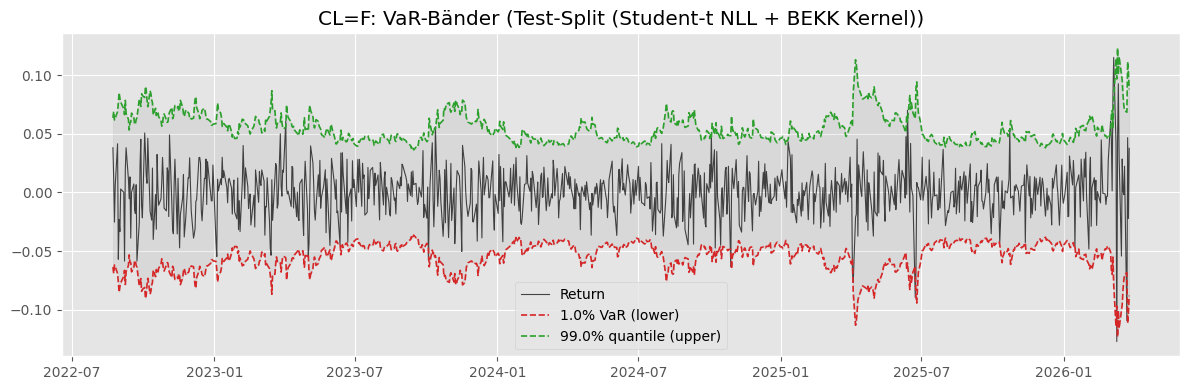

CL=F: hit rate = 0.999% (target 1.000%)


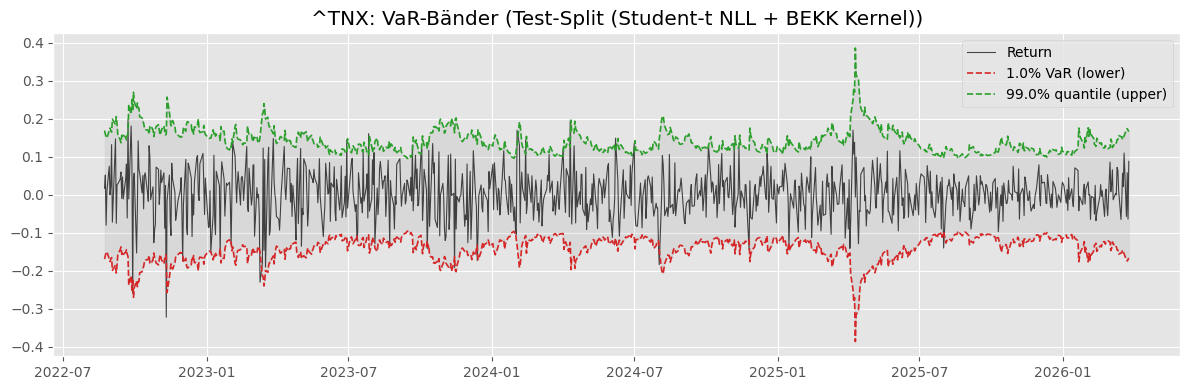

^TNX: hit rate = 1.887% (target 1.000%)


In [243]:
plot_var(alpha=0.01, lookback=lookback, cols=macro_tickers, view="Test-Split (Student-t NLL + BEKK Kernel)", df=test_df, pred_vol=sigma_test_real_bekk, loss_fn=student_nll, loss_kwargs=loss_kwargs)

## Portfolio

In [244]:
idx_test_bekk, rp_test_bekk, varp_test_bekk, volp_test_bekk = calc_portfolio_variance(
    test_df, sigma_test_real_bekk, macro_tickers, lookback, w_np
)

idx_val_bekk, rp_val_bekk, varp_val_bekk, volp_val_bekk = calc_portfolio_variance(
    val_df, sigma_val_real_bekk, macro_tickers, lookback, w_np
)

idx_train_bekk, rp_train_bekk, varp_train_bekk, volp_train_bekk = calc_portfolio_variance(
    train_df, sigma_train_real_bekk, macro_tickers, lookback, w_np
)

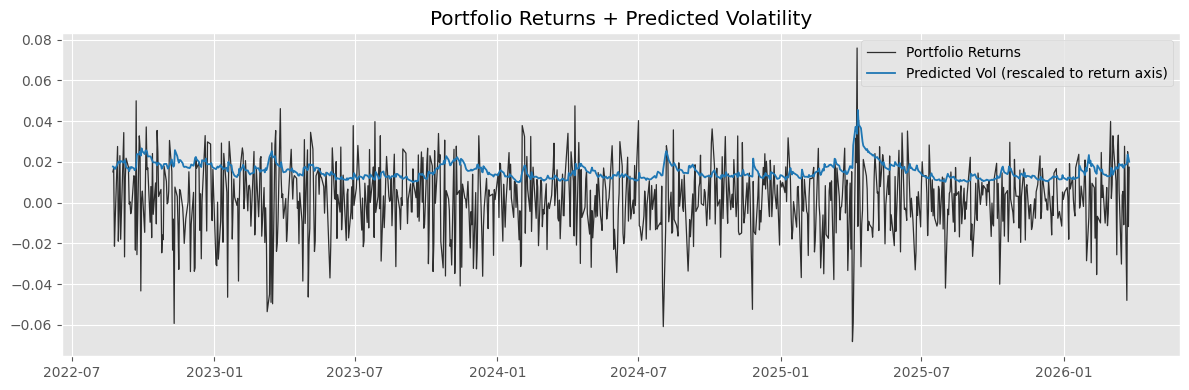

In [245]:
r = np.asarray(rp_test_bekk, dtype=float)
v = np.asarray(volp_test_bekk, dtype=float)

plt.figure(figsize=(12, 4))
plt.plot(idx_test_bekk, r, label="Portfolio Returns", color="black", lw=0.9, alpha=0.8)
plt.plot(idx_test_bekk, v, label="Predicted Vol (rescaled to return axis)", color="tab:blue", lw=1.3)
plt.title("Portfolio Returns + Predicted Volatility")
plt.legend()
plt.tight_layout()
plt.show()

In [246]:
portfolio_test_bekk = make_portfolio_df(idx_test_bekk, rp_test_bekk, varp_test_bekk, volp_test_bekk)
portfolio_val_bekk = make_portfolio_df(idx_val_bekk, rp_val_bekk, varp_val_bekk, volp_val_bekk)
portfolio_train_bekk = make_portfolio_df(idx_train_bekk, rp_train_bekk, varp_train_bekk, volp_train_bekk)

## FHS

In [247]:
z_train_bekk = portfolio_train_bekk["r_p"].values / np.clip(portfolio_train_bekk["vol_p"].values, 1e-12, None) # clip sichert nur nach unten ab (0 division)
z_val_bekk = portfolio_val_bekk["r_p"].values / np.clip(portfolio_val_bekk["vol_p"].values, 1e-12, None)
z_test_bekk = portfolio_test_bekk["r_p"].values / np.clip(portfolio_test_bekk["vol_p"].values, 1e-12, None)
z_train_val_bekk =np.concatenate([z_train_bekk, z_val_bekk])


var_fhs_test_bekk, es_fhs_test_bekk, hits_test_bekk = fhs_var_es(
    z_hist_init=z_train_val_bekk, # nimmt die letzen #window Werte als Historie
    r_oos=portfolio_test_bekk["r_p"].values,
    vol_oos=portfolio_test_bekk["vol_p"].values,
    alpha=alpha,
    window=window
)

hit_rate_test_bekk = hits_test_bekk.mean()
print(f"FHS Test hit rate = {hit_rate_test_bekk:.3%} (target {alpha:.3%})")

FHS Test hit rate = 1.221% (target 1.000%)


In [248]:
len(close)

6405

# Backtesting

!!! Backtestings müssen mit dem selben $\alpha$ vorgenommen werden wie mit FHS !!!

Backtests sind für univariate Zeitreihen definiert, d.h. wir testen alle Modelle im Kontext eines vordefinierten Portfolios.

In [ ]:
#importlib.reload(backtesting)

<module 'backtesting' from '/Users/bayesed/Desktop/Studium/Masterthesis/Code/neural_bekk/backtesting.py'>

In [249]:
from backtesting import run_backtest_suite

In [250]:
results = run_backtest_suite(
    returns=portfolio_test["r_p"].values,
    var=var_fhs_test,
    es=es_fhs_test,
    alpha=alpha,
    volatility=portfolio_test["vol_p"].values,  # optional, aber für CC/ER sinnvoll
)

results

{'meta': {'alpha': 0.01, 'n_obs': 901},
 'var': {'kupiec': {'test': 'kupiec_uc',
   'alpha': 0.01,
   'n_obs': 901,
   'n_exceptions': 9,
   'expected_exceptions': 9.01,
   'hit_rate': 0.009988901220865706,
   'lr_uc': 1.1214995964792251e-05,
   'p_value': 0.9973279855000853},
  'christoffersen': {'test': 'christoffersen_cc',
   'alpha': 0.01,
   'n_obs': 901,
   'n_exceptions': 9,
   'hit_rate': 0.009988901220865706,
   'transition_counts': {'n00': 883, 'n01': 8, 'n10': 8, 'n11': 1},
   'transition_probs': {'pi_01': 0.008978675645342313,
    'pi_11': 0.1111111111111111,
    'pi_pooled': 0.01},
   'lr_ind': 3.1893832940393025,
   'p_value_ind': 0.07411796809429466,
   'lr_uc': 1.1214995964792251e-05,
   'lr_cc': 3.1893945090352673,
   'p_value_cc': 0.2029699674425933}},
 'cc': {'pvalue_twosided_simple': 0.5196080348429148,
  'pvalue_onesided_simple': 1.0,
  'pvalue_twosided_general': 0.6523696490842068,
  'pvalue_onesided_general': 1.0,
  'n_obs': 901},
 'er': {'pvalue_twosided_simple'

In [251]:
results_student = run_backtest_suite(
    returns=portfolio_test_t["r_p"].values,
    var=var_fhs_test_t,
    es=es_fhs_test_t,
    alpha=alpha,
    volatility=portfolio_test_t["vol_p"].values,
)

results_student

{'meta': {'alpha': 0.01, 'n_obs': 901},
 'var': {'kupiec': {'test': 'kupiec_uc',
   'alpha': 0.01,
   'n_obs': 901,
   'n_exceptions': 10,
   'expected_exceptions': 9.01,
   'hit_rate': 0.011098779134295227,
   'lr_uc': 0.10609961333953777,
   'p_value': 0.7446291316351756},
  'christoffersen': {'test': 'christoffersen_cc',
   'alpha': 0.01,
   'n_obs': 901,
   'n_exceptions': 10,
   'hit_rate': 0.011098779134295227,
   'transition_counts': {'n00': 881, 'n01': 9, 'n10': 9, 'n11': 1},
   'transition_probs': {'pi_01': 0.010112359550561797,
    'pi_11': 0.1,
    'pi_pooled': 0.011111111111111112},
   'lr_ind': 2.782384642429207,
   'p_value_ind': 0.0953061680943967,
   'lr_uc': 0.10609961333953777,
   'lr_cc': 2.888484255768745,
   'p_value_cc': 0.23592480965351434}},
 'cc': {'pvalue_twosided_simple': 0.0564858703624056,
  'pvalue_onesided_simple': 1.0,
  'pvalue_twosided_general': 0.9333858108182416,
  'pvalue_onesided_general': 1.0,
  'n_obs': 901},
 'er': {'pvalue_twosided_simple': 0.9

In [252]:
results_bekk = run_backtest_suite(
    returns=portfolio_test_bekk["r_p"].values,
    var=var_fhs_test_bekk,
    es=es_fhs_test_bekk,
    alpha=alpha,
    volatility=portfolio_test_bekk["vol_p"].values,
)

results_bekk

{'meta': {'alpha': 0.01, 'n_obs': 901},
 'var': {'kupiec': {'test': 'kupiec_uc',
   'alpha': 0.01,
   'n_obs': 901,
   'n_exceptions': 11,
   'expected_exceptions': 9.01,
   'hit_rate': 0.01220865704772475,
   'lr_uc': 0.41476735492000216,
   'p_value': 0.5195596484511082},
  'christoffersen': {'test': 'christoffersen_cc',
   'alpha': 0.01,
   'n_obs': 901,
   'n_exceptions': 11,
   'hit_rate': 0.01220865704772475,
   'transition_counts': {'n00': 879, 'n01': 10, 'n10': 10, 'n11': 1},
   'transition_probs': {'pi_01': 0.01124859392575928,
    'pi_11': 0.09090909090909091,
    'pi_pooled': 0.012222222222222223},
   'lr_ind': 2.424666343489406,
   'p_value_ind': 0.11943867039857473,
   'lr_uc': 0.41476735492000216,
   'lr_cc': 2.839433698409408,
   'p_value_cc': 0.24178246810370452}},
 'cc': {'pvalue_twosided_simple': 0.07819766275007434,
  'pvalue_onesided_simple': 1.0,
  'pvalue_twosided_general': 0.3247347761801307,
  'pvalue_onesided_general': 1.0,
  'n_obs': 901},
 'er': {'pvalue_twos

# BEKK(1, 1) symmetrisch & asymmetrisch

importiert aus R bzw BEKKs Library.

In [ ]:
df_H = pd.read_csv("data/bekk_forecasts_symmetric.csv", parse_dates=["Date"])

H_values = df_H.drop(columns=["Date"]).to_numpy()

n = len(df_H)
d = 4

H_bekk = H_values.reshape(n, d, d)

H_bekk.shape


# Rolling Block Re-Estimation

In [ ]:
from rolling_forecast import run_block_reestimation

In [ ]:
result = run_block_reestimation(
    data=input_df,
    target_cols=macro_tickers,
    model_factory=lambda: LSTMCovariance(
        input_size=len(input_df.columns),
        n_assets=len(macro_tickers),
        hidden_size=64,
        num_layers=2,
        dropout=0.2,
    ),
    lookback=60,
    train_window=1000,
    refit_every=100,
    val_size=100,
    batch_size=64,
    device=device,
    loss_fn=student_nll,
    loss_kwargs=loss_kwargs,
    train_kwargs={"epochs": 200, "lr": 1e-4, "scheduler_type": "cosine"},
    verbose=False,
)